<a href="https://colab.research.google.com/github/AsimaZaheer/Research-Model-Stress-Detection/blob/main/Stress_Detection_16Hz_Resampling%2BCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
"""
WESAD Stress Detection Pipeline
================================
STEP 1: WESAD Dataset Inspection

Dataset Google Drive se automatically download hoga.
User ko apni Google Drive mount karne ki zarurat nahi.

IMPORTANT:
Sirf WESAD_ZIP_URL mein apna public Google Drive ZIP link paste karein.

Is step mein model training nahi hogi.
Pehle WESAD ke actual signals aur labels inspect honge.
"""


# ============================================================
# IMPORTS
# ============================================================

import os
import pickle
import zipfile
import numpy as np

from scipy import signal
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# DATASET DOWNLOAD CONFIGURATION
# ============================================================

# ============================================================
# IMPORTANT:
# YAHAN APNA GOOGLE DRIVE WESAD.ZIP LINK PASTE KAREIN
# ============================================================

WESAD_ZIP_URL = (
    "https://drive.google.com/file/d/"
    "1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l"
    "/view?usp=sharing"
)

# Temporary ZIP location in Google Colab
ZIP_PATH = "/content/WESAD.zip"

# Dataset extraction location
EXTRACT_PATH = "/content"


# ============================================================
# DOWNLOAD DATASET FROM GOOGLE DRIVE
# ============================================================

def download_wesad_dataset():

    print("=" * 60)
    print("WESAD DATASET SETUP")
    print("=" * 60)

    if WESAD_ZIP_URL == "PASTE_YOUR_GOOGLE_DRIVE_ZIP_LINK_HERE":

        raise ValueError(
            "\nPlease paste your Google Drive WESAD ZIP link "
            "inside WESAD_ZIP_URL."
        )

    # --------------------------------------------------------
    # Install gdown
    # --------------------------------------------------------

    print("\n📦 Installing gdown...")

    os.system("pip -q install gdown")

    import gdown

    # --------------------------------------------------------
    # Download ZIP
    # --------------------------------------------------------

    print("\n⬇️ Downloading WESAD dataset...")
    print(
        "This may take some time depending on internet speed.\n"
    )

    gdown.download(
        WESAD_ZIP_URL,
        ZIP_PATH,
        quiet=False,
        fuzzy=True
    )

    # --------------------------------------------------------
    # Check ZIP
    # --------------------------------------------------------

    if not os.path.exists(ZIP_PATH):

        raise FileNotFoundError(
            "WESAD ZIP file could not be downloaded."
        )

    print(
        "\n✅ WESAD ZIP downloaded successfully."
    )

    # --------------------------------------------------------
    # Extract ZIP
    # --------------------------------------------------------

    print(
        "\n📂 Extracting WESAD dataset..."
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_PATH
        )

    print(
        "✅ Dataset extracted successfully."
    )

    # --------------------------------------------------------
    # Find dataset folder
    # --------------------------------------------------------

    print(
        "\n📁 Checking extracted dataset structure..."
    )

    possible_paths = [

        "/content/WESAD",

        "/content/WESAD/WESAD",

    ]

    dataset_path = None

    # --------------------------------------------------------
    # Check common locations
    # --------------------------------------------------------

    for path in possible_paths:

        if os.path.isdir(path):

            dataset_path = path

            break

    # --------------------------------------------------------
    # Automatic search
    # --------------------------------------------------------

    if dataset_path is None:

        for root, dirs, files in os.walk(
            "/content"
        ):

            if "S2" in dirs:

                candidate = root

                s2_path = os.path.join(
                    candidate,
                    "S2"
                )

                if os.path.isdir(
                    s2_path
                ):

                    dataset_path = candidate

                    break

    # --------------------------------------------------------
    # Dataset not found
    # --------------------------------------------------------

    if dataset_path is None:

        raise FileNotFoundError(
            """
WESAD dataset folder could not be located.

Please make sure your ZIP contains:

WESAD/
    S2/
    S3/
    S4/
    ...
"""
        )

    print(
        "\n✅ Dataset location found:"
    )

    print(
        dataset_path
    )

    return dataset_path


# ============================================================
# AUTOMATICALLY DOWNLOAD DATASET
# ============================================================

DATASET_PATH = download_wesad_dataset()


# ============================================================
# CONFIGURATION
# ============================================================

SUBJECTS = [

    f"S{i}"

    for i in [

        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        13,
        14,
        15,
        16,
        17

    ]

]


# ============================================================
# SAMPLING CONFIGURATION
# ============================================================

TARGET_SAMPLING_RATE = 16

# IMPORTANT:
# Abhi label rate assume nahi kar rahe.
# Pehle actual WESAD dataset inspect hoga.

LABEL_NATIVE_RATE = None


# ============================================================
# WINDOW CONFIGURATION
# ============================================================

WINDOW_SIZE = 60

STEP_SIZE = 10


# ============================================================
# TRAINING CONFIGURATION
# ============================================================

BATCH_SIZE = 32


# ============================================================
# DEVICE
# ============================================================

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# PRINT CONFIGURATION
# ============================================================

print(
    "\n🖥️ Device:",
    DEVICE
)

print(
    "📁 Dataset:",
    DATASET_PATH
)

print(
    "👥 Subjects:",
    SUBJECTS
)

print(
    "📡 Target Sampling Rate:",
    TARGET_SAMPLING_RATE,
    "Hz"
)

print(
    "🏷️ Label Native Rate:",
    LABEL_NATIVE_RATE
)


# ============================================================
# HELPER: RESAMPLING
# ============================================================

def resample_signal(
    sig,
    orig_rate,
    target_rate
):

    n_samples = int(
        len(sig)
        * target_rate
        / orig_rate
    )

    return signal.resample(
        sig,
        n_samples
    )


# ============================================================
# LABEL ALIGNMENT
# ============================================================

def align_labels_by_time(
    labels_raw,
    label_rate,
    n_target_samples,
    target_rate
):

    target_times = (
        np.arange(
            n_target_samples
        )
        / target_rate
    )

    label_indices = np.round(
        target_times
        * label_rate
    ).astype(int)

    label_indices = np.clip(
        label_indices,
        0,
        len(labels_raw) - 1
    )

    return labels_raw[
        label_indices
    ]


# ============================================================
# HRV FEATURES
# ============================================================

def extract_hrv_features(
    bvp_window,
    fs
):

    peaks, _ = find_peaks(

        bvp_window,

        distance=max(
            1,
            int(fs * 0.4)
        ),

        prominence=0.1
    )

    if len(peaks) < 3:

        return np.array([
            np.nan,
            np.nan,
            np.nan
        ])

    rr_intervals = (
        np.diff(peaks)
        / fs
    )

    hr = (
        60.0
        / rr_intervals
    )

    mean_hr = np.mean(
        hr
    )

    sdnn = (
        np.std(
            rr_intervals
        )
        * 1000.0
    )

    rmssd = (
        np.sqrt(
            np.mean(
                np.diff(
                    rr_intervals
                ) ** 2
            )
        )
        * 1000.0
    )

    return np.array([
        mean_hr,
        sdnn,
        rmssd
    ])


# ============================================================
# WINDOWING + HRV FEATURES
# ============================================================

def create_windows_with_features(
    eda,
    bvp,
    labels,
    fs,
    window_size_s,
    step_size_s
):

    window_samples = int(
        window_size_s * fs
    )

    step_samples = int(
        step_size_s * fs
    )

    X_seq = []
    X_hrv = []
    y = []

    for i in range(
        0,
        len(eda) - window_samples,
        step_samples
    ):

        eda_win = eda[
            i:
            i + window_samples
        ]

        bvp_win = bvp[
            i:
            i + window_samples
        ]

        label_win = labels[
            i:
            i + window_samples
        ]

        unique_labels, counts = np.unique(
            label_win,
            return_counts=True
        )

        majority_label = unique_labels[
            np.argmax(counts)
        ]

        # ----------------------------------------------------
        # Valid WESAD labels
        #
        # 1 = Baseline
        # 2 = Stress
        # 3 = Amusement
        # ----------------------------------------------------

        if majority_label in [1, 2, 3]:

            hrv_feats = extract_hrv_features(
                bvp_win,
                fs
            )

            if np.isnan(
                hrv_feats
            ).any():

                continue

            # ------------------------------------------------
            # EDA + BVP
            # ------------------------------------------------

            seq_window = np.column_stack(
                (
                    eda_win,
                    bvp_win
                )
            )

            X_seq.append(
                seq_window
            )

            X_hrv.append(
                hrv_feats
            )

            # ------------------------------------------------
            # Label conversion
            #
            # 1 -> 0 Baseline
            # 2 -> 1 Stress
            # 3 -> 2 Amusement
            # ------------------------------------------------

            y.append(
                majority_label - 1
            )

    return (
        np.array(X_seq),
        np.array(X_hrv),
        np.array(y)
    )


# ============================================================
# CNN + HRV MODEL
# ============================================================

class StressClassifier(
    nn.Module
):

    def __init__(
        self,
        seq_channels=2,
        hrv_dim=3,
        n_classes=3
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv1d(
                seq_channels,
                16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                2
            ),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(
                1
            )

        )

        self.classifier = nn.Sequential(

            nn.Linear(
                32 + hrv_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                n_classes
            )

        )

    def forward(
        self,
        x_seq,
        x_hrv
    ):

        # Input:
        # (batch, window_length, channels)

        x = x_seq.permute(
            0,
            2,
            1
        )

        x = self.conv(
            x
        )

        x = x.squeeze(
            -1
        )

        # Add HRV features

        x = torch.cat(
            [
                x,
                x_hrv
            ],
            dim=1
        )

        return self.classifier(
            x
        )


# ============================================================
# WESAD DATA INSPECTION
# IMPORTANT:
# YE FUNCTION CLASS KE BAHAR HAI
# ============================================================

def inspect_subject(
    dataset_path,
    sub="S2"
):

    file_path = os.path.join(
        dataset_path,
        sub,
        f"{sub}.pkl"
    )

    print(
        "\n" + "=" * 70
    )

    print(
        f"🔍 INSPECTING WESAD SUBJECT: {sub}"
    )

    print(
        "=" * 70
    )

    # --------------------------------------------------------
    # File path
    # --------------------------------------------------------

    print(
        "\n📁 File path:"
    )

    print(
        file_path
    )

    # --------------------------------------------------------
    # Check file
    # --------------------------------------------------------

    if not os.path.exists(
        file_path
    ):

        raise FileNotFoundError(
            f"\n❌ File not found:\n{file_path}"
        )

    print(
        "\n✅ Subject file found."
    )

    # --------------------------------------------------------
    # Load pickle
    # --------------------------------------------------------

    print(
        "\n📥 Loading subject data..."
    )

    with open(
        file_path,
        "rb"
    ) as f:

        data = pickle.load(
            f,
            encoding="latin1"
        )

    print(
        "✅ Subject data loaded."
    )

    # --------------------------------------------------------
    # Top-level keys
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "1. TOP-LEVEL KEYS"
    )

    print(
        "-" * 70
    )

    print(
        data.keys()
    )

    # --------------------------------------------------------
    # Signal keys
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "2. SIGNAL KEYS"
    )

    print(
        "-" * 70
    )

    print(
        data["signal"].keys()
    )

    # --------------------------------------------------------
    # Wrist signal keys
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "3. WRIST SIGNAL KEYS"
    )

    print(
        "-" * 70
    )

    wrist = data[
        "signal"
    ][
        "wrist"
    ]

    print(
        wrist.keys()
    )

    # --------------------------------------------------------
    # Chest signal keys
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "4. CHEST SIGNAL KEYS"
    )

    print(
        "-" * 70
    )

    chest = data[
        "signal"
    ][
        "chest"
    ]

    print(
        chest.keys()
    )

    # --------------------------------------------------------
    # Wrist signal shapes
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "5. WRIST SIGNAL SHAPES"
    )

    print(
        "-" * 70
    )

    for key, value in wrist.items():

        try:

            print(
                f"{key:15s} "
                f"-> shape = "
                f"{np.asarray(value).shape}"
            )

        except Exception:

            print(
                f"{key:15s} "
                "-> unable to determine shape"
            )

    # --------------------------------------------------------
    # Chest signal shapes
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "6. CHEST SIGNAL SHAPES"
    )

    print(
        "-" * 70
    )

    for key, value in chest.items():

        try:

            print(
                f"{key:15s} "
                f"-> shape = "
                f"{np.asarray(value).shape}"
            )

        except Exception:

            print(
                f"{key:15s} "
                "-> unable to determine shape"
            )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "7. LABEL INFORMATION"
    )

    print(
        "-" * 70
    )

    labels = np.asarray(
        data["label"]
    ).flatten()

    print(
        "Label shape:"
    )

    print(
        labels.shape
    )

    print(
        "\nLabel dtype:"
    )

    print(
        labels.dtype
    )

    print(
        "\nNumber of labels:"
    )

    print(
        len(labels)
    )

    # --------------------------------------------------------
    # Unique labels
    # --------------------------------------------------------

    unique_labels, counts = np.unique(
        labels,
        return_counts=True
    )

    print(
        "\n" + "-" * 70
    )

    print(
        "8. UNIQUE LABELS"
    )

    print(
        "-" * 70
    )

    print(
        "Unique labels:"
    )

    print(
        unique_labels
    )

    print(
        "\nLabel counts:"
    )

    for label, count in zip(
        unique_labels,
        counts
    ):

        print(
            f"Label {label}: "
            f"{count} samples"
        )

    # --------------------------------------------------------
    # First 20 labels
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "9. FIRST 20 LABELS"
    )

    print(
        "-" * 70
    )

    print(
        labels[:20]
    )

    # --------------------------------------------------------
    # Last 20 labels
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "10. LAST 20 LABELS"
    )

    print(
        "-" * 70
    )

    print(
        labels[-20:]
    )

    # --------------------------------------------------------
    # Compare signal lengths
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "11. WRIST SIGNAL LENGTHS"
    )

    print(
        "-" * 70
    )

    for key, value in wrist.items():

        try:

            arr = np.asarray(
                value
            )

            print(
                f"{key:15s}: "
                f"{len(arr)} samples"
            )

        except Exception:

            print(
                f"{key:15s}: "
                "unable to determine length"
            )

    # --------------------------------------------------------
    # Approximate duration
    # --------------------------------------------------------

    print(
        "\n" + "-" * 70
    )

    print(
        "12. APPROXIMATE SIGNAL DURATION"
    )

    print(
        "-" * 70
    )

    if "EDA" in wrist:

        eda_length = len(
            np.asarray(
                wrist["EDA"]
            ).flatten()
        )

        print(
            f"EDA samples: "
            f"{eda_length}"
        )

        print(
            f"EDA duration at 4 Hz: "
            f"{eda_length / 4:.2f} seconds"
        )

    if "BVP" in wrist:

        bvp_length = len(
            np.asarray(
                wrist["BVP"]
            ).flatten()
        )

        print(
            f"BVP samples: "
            f"{bvp_length}"
        )

        print(
            f"BVP duration at 64 Hz: "
            f"{bvp_length / 64:.2f} seconds"
        )

    print(
        f"Label samples: "
        f"{len(labels)}"
    )

    # --------------------------------------------------------
    # Finish
    # --------------------------------------------------------

    print(
        "\n" + "=" * 70
    )

    print(
        "✅ INSPECTION COMPLETED"
    )

    print(
        "=" * 70
    )

    print(
        "\n⚠️ Model training has NOT started."
    )

    print(
        "Please send me this complete output."
    )

    print(
        "After checking it, we will fix the "
        "label alignment correctly."
    )


# ============================================================
# WESAD PIPELINE CLASS
# ============================================================
# NOTE:
# Model aur original pipeline yahan intentionally abhi
# execute nahi ki ja rahi.
#
# Hum pehle dataset structure verify kar rahe hain.
# ============================================================


class WESADPipeline:

    def __init__(
        self,
        dataset_path,
        subjects,
        fs=TARGET_SAMPLING_RATE,
        label_rate=LABEL_NATIVE_RATE,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE
    ):

        self.dataset_path = dataset_path

        self.subjects = subjects

        self.fs = fs

        self.label_rate = label_rate

        self.window_size = window_size

        self.step_size = step_size


# ============================================================
# RUN STEP 1
# ============================================================

if __name__ == "__main__":

    print(
        "\n🔍 Starting WESAD dataset inspection..."
    )

    inspect_subject(
        DATASET_PATH,
        "S2"
    )

    print(
        "\n" + "=" * 70
    )

    print(
        "STEP 1 FINISHED"
    )

    print(
        "=" * 70
    )

    print(
        "\n👉 Abhi LOSO training run nahi hui."
    )

    print(
        "👉 Abhi CNN training run nahi hui."
    )

    print(
        "👉 Abhi labels ko assume nahi kiya gaya."
    )

    print(
        "\n📌 Mujhe upar ka complete output bhej dein."
    )

WESAD DATASET SETUP

📦 Installing gdown...

⬇️ Downloading WESAD dataset...
This may take some time depending on internet speed.



Downloading...
From (original): https://drive.google.com/uc?id=1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l
From (redirected): https://drive.google.com/uc?id=1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l&confirm=t&uuid=cd55aee8-316c-41e6-89f5-70a70bbbb29d
To: /content/WESAD.zip
100%|██████████| 2.25G/2.25G [00:25<00:00, 87.6MB/s]



✅ WESAD ZIP downloaded successfully.

📂 Extracting WESAD dataset...
✅ Dataset extracted successfully.

📁 Checking extracted dataset structure...

✅ Dataset location found:
/content/WESAD

🖥️ Device: cpu
📁 Dataset: /content/WESAD
👥 Subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
📡 Target Sampling Rate: 16 Hz
🏷️ Label Native Rate: None

🔍 Starting WESAD dataset inspection...

🔍 INSPECTING WESAD SUBJECT: S2

📁 File path:
/content/WESAD/S2/S2.pkl

✅ Subject file found.

📥 Loading subject data...
✅ Subject data loaded.

----------------------------------------------------------------------
1. TOP-LEVEL KEYS
----------------------------------------------------------------------
dict_keys(['signal', 'label', 'subject'])

----------------------------------------------------------------------
2. SIGNAL KEYS
----------------------------------------------------------------------
dict_keys(['chest', 'wrist'])

---------------------------

In [6]:
"""
WESAD Stress Detection Pipeline
================================
STEP 2:
- Download WESAD dataset from Google Drive
- Inspect dataset
- Verify label sampling rate
- Inspect continuous label segments
- NO CNN TRAINING
- NO LOSO TRAINING

Original CNN + HRV pipeline is preserved for later use.
"""

# ============================================================
# IMPORTS
# ============================================================

import os
import pickle
import zipfile
import numpy as np

from scipy import signal
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# DATASET DOWNLOAD CONFIGURATION
# ============================================================

WESAD_ZIP_URL = (
    "https://drive.google.com/file/d/"
    "1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l/view?usp=sharing"
)

# Temporary ZIP location
ZIP_PATH = "/content/WESAD.zip"

# Dataset extraction location
EXTRACT_PATH = "/content"


# ============================================================
# DOWNLOAD DATASET FROM GOOGLE DRIVE
# ============================================================

def download_wesad_dataset():

    print("=" * 60)
    print("WESAD DATASET SETUP")
    print("=" * 60)

    if WESAD_ZIP_URL == "PASTE_YOUR_GOOGLE_DRIVE_ZIP_LINK_HERE":
        raise ValueError(
            "\nPlease paste your Google Drive WESAD ZIP link "
            "inside WESAD_ZIP_URL."
        )

    # --------------------------------------------------------
    # Install gdown
    # --------------------------------------------------------

    print("\n📦 Installing gdown...")

    os.system("pip -q install gdown")

    import gdown

    # --------------------------------------------------------
    # Download ZIP
    # --------------------------------------------------------

    print("\n⬇️ Downloading WESAD dataset...")
    print("This may take some time depending on internet speed.\n")

    gdown.download(
        WESAD_ZIP_URL,
        ZIP_PATH,
        quiet=False,
        fuzzy=True
    )

    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(
            "WESAD ZIP file could not be downloaded."
        )

    print("\n✅ WESAD ZIP downloaded successfully.")

    # --------------------------------------------------------
    # Extract ZIP
    # --------------------------------------------------------

    print("\n📂 Extracting WESAD dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("✅ Dataset extracted successfully.")

    # --------------------------------------------------------
    # Find dataset folder
    # --------------------------------------------------------

    print("\n📁 Checking extracted dataset structure...")

    possible_paths = [
        "/content/WESAD",
        "/content/WESAD/WESAD"
    ]

    dataset_path = None

    for path in possible_paths:

        if os.path.isdir(path):

            dataset_path = path
            break

    # --------------------------------------------------------
    # Automatic search if not found
    # --------------------------------------------------------

    if dataset_path is None:

        for root, dirs, files in os.walk("/content"):

            if "S2" in dirs:

                candidate = root
                s2_path = os.path.join(candidate, "S2")

                if os.path.isdir(s2_path):

                    dataset_path = candidate
                    break

    if dataset_path is None:

        raise FileNotFoundError(
            """
WESAD dataset folder could not be located.

Please make sure your ZIP contains:

WESAD/
    S2/
    S3/
    S4/
    S5/
    ...
"""
        )

    print("\n✅ Dataset location found:")
    print(dataset_path)

    return dataset_path


# ============================================================
# AUTOMATICALLY DOWNLOAD DATASET
# ============================================================

DATASET_PATH = download_wesad_dataset()


# ============================================================
# CONFIG
# ============================================================

SUBJECTS = [
    f"S{i}"
    for i in [
        2, 3, 4, 5, 6, 7, 8,
        9, 10, 11, 13, 14, 15, 16, 17
    ]
]


# ============================================================
# SAMPLING CONFIGURATION
# ============================================================

TARGET_SAMPLING_RATE = 16

# WESAD label signal is 700 Hz
LABEL_NATIVE_RATE = 700

WINDOW_SIZE = 60
STEP_SIZE = 10

BATCH_SIZE = 32

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("\n🖥️ Device:", DEVICE)
print("📁 Dataset:", DATASET_PATH)
print("👥 Subjects:", SUBJECTS)
print(
    "📡 Target Sampling Rate:",
    TARGET_SAMPLING_RATE,
    "Hz"
)
print(
    "🏷️ Label Native Rate:",
    LABEL_NATIVE_RATE,
    "Hz"
)


# ============================================================
# HELPER: RESAMPLING
# ============================================================

def resample_signal(
    sig,
    orig_rate,
    target_rate
):

    n_samples = int(
        len(sig)
        * target_rate
        / orig_rate
    )

    return signal.resample(
        sig,
        n_samples
    )


# ============================================================
# LABEL ALIGNMENT
# ============================================================

def align_labels_by_time(
    labels_raw,
    label_rate,
    n_target_samples,
    target_rate
):

    target_times = (
        np.arange(n_target_samples)
        / target_rate
    )

    label_indices = np.round(
        target_times
        * label_rate
    ).astype(int)

    label_indices = np.clip(
        label_indices,
        0,
        len(labels_raw) - 1
    )

    return labels_raw[label_indices]


# ============================================================
# HRV FEATURES
# ============================================================

def extract_hrv_features(
    bvp_window,
    fs
):

    peaks, _ = find_peaks(
        bvp_window,
        distance=max(
            1,
            int(fs * 0.4)
        ),
        prominence=0.1
    )

    if len(peaks) < 3:

        return np.array([
            np.nan,
            np.nan,
            np.nan
        ])

    rr_intervals = (
        np.diff(peaks)
        / fs
    )

    hr = (
        60.0
        / rr_intervals
    )

    mean_hr = np.mean(hr)

    sdnn = (
        np.std(rr_intervals)
        * 1000.0
    )

    rmssd = (
        np.sqrt(
            np.mean(
                np.diff(
                    rr_intervals
                ) ** 2
            )
        )
        * 1000.0
    )

    return np.array([
        mean_hr,
        sdnn,
        rmssd
    ])


# ============================================================
# WINDOWING + HRV FEATURES
# ============================================================

def create_windows_with_features(
    eda,
    bvp,
    labels,
    fs,
    window_size_s,
    step_size_s
):

    window_samples = int(
        window_size_s * fs
    )

    step_samples = int(
        step_size_s * fs
    )

    X_seq = []
    X_hrv = []
    y = []

    for i in range(
        0,
        len(eda) - window_samples,
        step_samples
    ):

        eda_win = eda[
            i:i + window_samples
        ]

        bvp_win = bvp[
            i:i + window_samples
        ]

        label_win = labels[
            i:i + window_samples
        ]

        unique_labels, counts = np.unique(
            label_win,
            return_counts=True
        )

        majority_label = unique_labels[
            np.argmax(counts)
        ]

        # ----------------------------------------------------
        # Current 3-class mapping
        # 1 = Baseline
        # 2 = Stress
        # 3 = Amusement
        # ----------------------------------------------------

        if majority_label in [1, 2, 3]:

            hrv_feats = extract_hrv_features(
                bvp_win,
                fs
            )

            if np.isnan(
                hrv_feats
            ).any():

                continue

            # EDA + BVP

            seq_window = np.column_stack(
                (
                    eda_win,
                    bvp_win
                )
            )

            X_seq.append(
                seq_window
            )

            X_hrv.append(
                hrv_feats
            )

            # ------------------------------------------------
            # Convert labels:
            #
            # 1 -> 0 Baseline
            # 2 -> 1 Stress
            # 3 -> 2 Amusement
            # ------------------------------------------------

            y.append(
                majority_label - 1
            )

    return (
        np.array(X_seq),
        np.array(X_hrv),
        np.array(y)
    )


# ============================================================
# CNN + HRV MODEL
# ============================================================

class StressClassifier(nn.Module):

    def __init__(
        self,
        seq_channels=2,
        hrv_dim=3,
        n_classes=3
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv1d(
                seq_channels,
                16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                32 + hrv_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                n_classes
            )
        )

    def forward(
        self,
        x_seq,
        x_hrv
    ):

        # Input:
        # (batch, window_length, channels)

        x = x_seq.permute(
            0,
            2,
            1
        )

        x = self.conv(x)

        x = x.squeeze(-1)

        # Add HRV features

        x = torch.cat(
            [
                x,
                x_hrv
            ],
            dim=1
        )

        return self.classifier(x)


# ============================================================
# STEP 2:
# WESAD DATA INSPECTION
# ============================================================

def inspect_subject(
    dataset_path,
    sub="S2"
):

    print("\n")
    print("=" * 70)
    print(
        f"🔍 INSPECTING WESAD SUBJECT: {sub}"
    )
    print("=" * 70)

    file_path = os.path.join(
        dataset_path,
        sub,
        f"{sub}.pkl"
    )

    print("\n📁 File path:")
    print(file_path)

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    print("\n✅ Subject file found.")

    print("\n📥 Loading subject data...")

    with open(
        file_path,
        "rb"
    ) as f:

        data = pickle.load(
            f,
            encoding="latin1"
        )

    print("✅ Subject data loaded.")

    # ========================================================
    # 1. TOP LEVEL KEYS
    # ========================================================

    print("\n" + "-" * 70)
    print("1. TOP-LEVEL KEYS")
    print("-" * 70)

    print(data.keys())

    # ========================================================
    # 2. SIGNAL KEYS
    # ========================================================

    print("\n" + "-" * 70)
    print("2. SIGNAL KEYS")
    print("-" * 70)

    print(data["signal"].keys())

    # ========================================================
    # 3. WRIST SIGNAL KEYS
    # ========================================================

    print("\n" + "-" * 70)
    print("3. WRIST SIGNAL KEYS")
    print("-" * 70)

    print(
        data["signal"]["wrist"].keys()
    )

    # ========================================================
    # 4. CHEST SIGNAL KEYS
    # ========================================================

    print("\n" + "-" * 70)
    print("4. CHEST SIGNAL KEYS")
    print("-" * 70)

    print(
        data["signal"]["chest"].keys()
    )

    # ========================================================
    # 5. WRIST SIGNAL SHAPES
    # ========================================================

    print("\n" + "-" * 70)
    print("5. WRIST SIGNAL SHAPES")
    print("-" * 70)

    wrist = data["signal"]["wrist"]

    for key, value in wrist.items():

        try:

            print(
                f"{key:<15} -> "
                f"shape = "
                f"{np.asarray(value).shape}"
            )

        except Exception:

            print(
                f"{key:<15} -> "
                "shape unavailable"
            )

    # ========================================================
    # 6. CHEST SIGNAL SHAPES
    # ========================================================

    print("\n" + "-" * 70)
    print("6. CHEST SIGNAL SHAPES")
    print("-" * 70)

    chest = data["signal"]["chest"]

    for key, value in chest.items():

        try:

            print(
                f"{key:<15} -> "
                f"shape = "
                f"{np.asarray(value).shape}"
            )

        except Exception:

            print(
                f"{key:<15} -> "
                "shape unavailable"
            )

    # ========================================================
    # 7. LABEL INFORMATION
    # ========================================================

    print("\n" + "-" * 70)
    print("7. LABEL INFORMATION")
    print("-" * 70)

    labels = np.asarray(
        data["label"]
    ).flatten()

    print("Label shape:")
    print(labels.shape)

    print("\nLabel dtype:")
    print(labels.dtype)

    print("\nNumber of labels:")
    print(len(labels))

    # ========================================================
    # 8. UNIQUE LABELS
    # ========================================================

    print("\n" + "-" * 70)
    print("8. UNIQUE LABELS")
    print("-" * 70)

    unique, counts = np.unique(
        labels,
        return_counts=True
    )

    print("Unique labels:")
    print(unique)

    print("\nLabel counts:")

    for label, count in zip(
        unique,
        counts
    ):

        print(
            f"Label {label}: "
            f"{count} samples"
        )

    # ========================================================
    # 9. FIRST LABELS
    # ========================================================

    print("\n" + "-" * 70)
    print("9. FIRST 20 LABELS")
    print("-" * 70)

    print(labels[:20])

    # ========================================================
    # 10. LAST LABELS
    # ========================================================

    print("\n" + "-" * 70)
    print("10. LAST 20 LABELS")
    print("-" * 70)

    print(labels[-20:])

    # ========================================================
    # 11. WRIST SIGNAL LENGTHS
    # ========================================================

    print("\n" + "-" * 70)
    print("11. WRIST SIGNAL LENGTHS")
    print("-" * 70)

    for key, value in wrist.items():

        try:

            print(
                f"{key:<15}: "
                f"{len(np.asarray(value))} "
                "samples"
            )

        except Exception:

            pass

    # ========================================================
    # 12. APPROXIMATE SIGNAL DURATION
    # ========================================================

    print("\n" + "-" * 70)
    print("12. APPROXIMATE SIGNAL DURATION")
    print("-" * 70)

    eda_len = len(
        np.asarray(
            wrist["EDA"]
        ).flatten()
    )

    bvp_len = len(
        np.asarray(
            wrist["BVP"]
        ).flatten()
    )

    label_len = len(labels)

    eda_duration = (
        eda_len / 4
    )

    bvp_duration = (
        bvp_len / 64
    )

    label_duration = (
        label_len
        / LABEL_NATIVE_RATE
    )

    print(
        f"EDA samples: {eda_len}"
    )

    print(
        f"EDA duration at 4 Hz: "
        f"{eda_duration:.2f} seconds"
    )

    print(
        f"BVP samples: {bvp_len}"
    )

    print(
        f"BVP duration at 64 Hz: "
        f"{bvp_duration:.2f} seconds"
    )

    print(
        f"Label samples: {label_len}"
    )

    print(
        f"Label duration at "
        f"{LABEL_NATIVE_RATE} Hz: "
        f"{label_duration:.2f} seconds"
    )

    # ========================================================
    # 13. DURATION COMPARISON
    # ========================================================

    print("\n" + "-" * 70)
    print("13. DURATION COMPARISON")
    print("-" * 70)

    print(
        f"EDA duration   : "
        f"{eda_duration:.2f} sec"
    )

    print(
        f"BVP duration   : "
        f"{bvp_duration:.2f} sec"
    )

    print(
        f"Label duration : "
        f"{label_duration:.2f} sec"
    )

    print(
        "\nDifference between EDA and labels: "
        f"{abs(eda_duration - label_duration):.4f} sec"
    )

    print(
        "Difference between BVP and labels: "
        f"{abs(bvp_duration - label_duration):.4f} sec"
    )

    print("\n" + "=" * 70)
    print("✅ SUBJECT INSPECTION COMPLETED")
    print("=" * 70)


# ============================================================
# STEP 2:
# LABEL SEGMENT INSPECTION
# ============================================================

def inspect_label_segments(
    dataset_path,
    sub="S2"
):

    print("\n")
    print("=" * 70)
    print(
        f"🏷️ LABEL SEGMENT INSPECTION: {sub}"
    )
    print("=" * 70)

    file_path = os.path.join(
        dataset_path,
        sub,
        f"{sub}.pkl"
    )

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    # --------------------------------------------------------
    # Load subject
    # --------------------------------------------------------

    print("\n📥 Loading labels...")

    with open(
        file_path,
        "rb"
    ) as f:

        data = pickle.load(
            f,
            encoding="latin1"
        )

    labels = np.asarray(
        data["label"]
    ).flatten()

    label_rate = LABEL_NATIVE_RATE

    # --------------------------------------------------------
    # Basic information
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print("LABEL TIMING INFORMATION")
    print("-" * 70)

    print(
        f"Label sampling rate: "
        f"{label_rate} Hz"
    )

    print(
        f"Total label samples: "
        f"{len(labels)}"
    )

    total_seconds = (
        len(labels)
        / label_rate
    )

    print(
        f"Total duration: "
        f"{total_seconds:.2f} seconds"
    )

    print(
        f"Total duration: "
        f"{total_seconds / 60:.2f} minutes"
    )

    # --------------------------------------------------------
    # Find label changes
    # --------------------------------------------------------

    changes = np.where(
        labels[1:] != labels[:-1]
    )[0] + 1

    starts = np.concatenate(
        (
            [0],
            changes
        )
    )

    ends = np.concatenate(
        (
            changes,
            [len(labels)]
        )
    )

    # --------------------------------------------------------
    # Continuous segments
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print("CONTINUOUS LABEL SEGMENTS")
    print("-" * 70)

    print(
        f"{'Label':<10}"
        f"{'Start(s)':<15}"
        f"{'End(s)':<15}"
        f"{'Duration(s)':<15}"
    )

    print("-" * 55)

    for start, end in zip(
        starts,
        ends
    ):

        label = int(
            labels[start]
        )

        start_time = (
            start / label_rate
        )

        end_time = (
            end / label_rate
        )

        duration = (
            (end - start)
            / label_rate
        )

        print(
            f"{label:<10}"
            f"{start_time:<15.2f}"
            f"{end_time:<15.2f}"
            f"{duration:<15.2f}"
        )

    # --------------------------------------------------------
    # Label summary
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print("LABEL SUMMARY")
    print("-" * 70)

    unique_labels = np.unique(
        labels
    )

    for label in unique_labels:

        count = np.sum(
            labels == label
        )

        duration = (
            count / label_rate
        )

        print(
            f"Label {int(label)} -> "
            f"{count} samples -> "
            f"{duration:.2f} seconds -> "
            f"{duration / 60:.2f} minutes"
        )

    # --------------------------------------------------------
    # Expected 3-class labels
    # --------------------------------------------------------

    print("\n" + "-" * 70)
    print("CURRENT 3-CLASS PIPELINE LABELS")
    print("-" * 70)

    print(
        "1 = Baseline"
    )

    print(
        "2 = Stress"
    )

    print(
        "3 = Amusement"
    )

    print(
        "\n⚠️ Labels 0, 4, 6, 7 are currently "
        "not used by the 3-class windowing function."
    )

    print("\n" + "=" * 70)
    print("✅ LABEL SEGMENT INSPECTION COMPLETED")
    print("=" * 70)

    print("\n⚠️ CNN training has NOT started.")
    print("⚠️ LOSO training has NOT started.")
    print("⚠️ No model accuracy has been calculated.")


# ============================================================
# WESAD PIPELINE CLASS
# ============================================================
# Original pipeline functionality preserved.
# Training is NOT called in Step 2.

class WESADPipeline:

    def __init__(
        self,
        dataset_path,
        subjects,
        fs=TARGET_SAMPLING_RATE,
        label_rate=LABEL_NATIVE_RATE,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE
    ):

        self.dataset_path = dataset_path
        self.subjects = subjects
        self.fs = fs
        self.label_rate = label_rate
        self.window_size = window_size
        self.step_size = step_size

    # ========================================================
    # LOAD SUBJECT
    # ========================================================

    def load_subject_raw(
        self,
        sub
    ):

        file_path = os.path.join(
            self.dataset_path,
            sub,
            f"{sub}.pkl"
        )

        if not os.path.exists(
            file_path
        ):

            print(
                f"⚠️ {file_path} not found."
            )

            return None

        print(
            f"Loading {sub}..."
        )

        with open(
            file_path,
            "rb"
        ) as f:

            data = pickle.load(
                f,
                encoding="latin1"
            )

        # ----------------------------------------------------
        # Extract signals
        # ----------------------------------------------------

        eda_raw = data[
            "signal"
        ][
            "wrist"
        ][
            "EDA"
        ].flatten()

        bvp_raw = data[
            "signal"
        ][
            "wrist"
        ][
            "BVP"
        ].flatten()

        labels_raw = data[
            "label"
        ].flatten()

        # ----------------------------------------------------
        # Resample
        # ----------------------------------------------------

        eda_resampled = resample_signal(
            eda_raw,
            4,
            self.fs
        )

        bvp_resampled = resample_signal(
            bvp_raw,
            64,
            self.fs
        )

        # ----------------------------------------------------
        # Same length
        # ----------------------------------------------------

        n_target = min(
            len(eda_resampled),
            len(bvp_resampled)
        )

        eda_resampled = (
            eda_resampled[:n_target]
        )

        bvp_resampled = (
            bvp_resampled[:n_target]
        )

        # ----------------------------------------------------
        # Align labels
        # ----------------------------------------------------

        labels_aligned = (
            align_labels_by_time(
                labels_raw,
                self.label_rate,
                n_target,
                self.fs
            )
        )

        return (
            eda_resampled,
            bvp_resampled,
            labels_aligned
        )

    # ========================================================
    # BUILD WINDOWS FOR ALL SUBJECTS
    # ========================================================

    def build_all_subject_windows(
        self
    ):

        X_seq_list = []
        X_hrv_list = []
        y_list = []
        groups_list = []

        for sub in self.subjects:

            loaded = (
                self.load_subject_raw(
                    sub
                )
            )

            if loaded is None:
                continue

            eda, bvp, labels = loaded

            (
                X_seq,
                X_hrv,
                y
            ) = create_windows_with_features(
                eda,
                bvp,
                labels,
                self.fs,
                self.window_size,
                self.step_size
            )

            if len(y) == 0:

                print(
                    f"⚠️ {sub}: "
                    "No valid windows."
                )

                continue

            X_seq_list.append(
                X_seq
            )

            X_hrv_list.append(
                X_hrv
            )

            y_list.append(
                y
            )

            groups_list.append(
                np.full(
                    len(y),
                    sub
                )
            )

            print(
                f"  {sub}: "
                f"{len(y)} windows"
            )

        # ----------------------------------------------------
        # Combine all subjects
        # ----------------------------------------------------

        X_seq_all = np.concatenate(
            X_seq_list,
            axis=0
        )

        X_hrv_all = np.concatenate(
            X_hrv_list,
            axis=0
        )

        y_all = np.concatenate(
            y_list,
            axis=0
        )

        groups_all = np.concatenate(
            groups_list,
            axis=0
        )

        return (
            X_seq_all,
            X_hrv_all,
            y_all,
            groups_all
        )

    # ========================================================
    # LOSO CROSS VALIDATION
    # ========================================================
    # Kept unchanged for later.
    # DO NOT call this function in Step 2.

    def run_loso(
        self,
        epochs=15,
        lr=1e-3,
        device=DEVICE
    ):

        print(
            "\n⏳ Loading and processing all subjects..."
        )

        (
            X_seq_all,
            X_hrv_all,
            y_all,
            groups_all
        ) = self.build_all_subject_windows()

        # ----------------------------------------------------
        # Class distribution
        # ----------------------------------------------------

        unique, counts = np.unique(
            y_all,
            return_counts=True
        )

        print(
            "\n📊 Overall class distribution:"
        )

        print(
            dict(
                zip(
                    unique,
                    counts
                )
            )
        )

        # ----------------------------------------------------
        # LOSO
        # ----------------------------------------------------

        logo = LeaveOneGroupOut()

        fold_reports = []

        total_folds = len(
            np.unique(
                groups_all
            )
        )

        for fold_idx, (
            train_idx,
            test_idx
        ) in enumerate(
            logo.split(
                X_seq_all,
                y_all,
                groups_all
            )
        ):

            test_subject = (
                groups_all[
                    test_idx
                ][0]
            )

            print(
                "\n"
                + "=" * 60
            )

            print(
                f"FOLD "
                f"{fold_idx + 1}/"
                f"{total_folds}"
            )

            print(
                f"Test Subject: "
                f"{test_subject}"
            )

            print(
                "=" * 60
            )

            # ------------------------------------------------
            # Train/Test split
            # ------------------------------------------------

            X_seq_train = (
                X_seq_all[
                    train_idx
                ]
            )

            X_seq_test = (
                X_seq_all[
                    test_idx
                ]
            )

            X_hrv_train = (
                X_hrv_all[
                    train_idx
                ]
            )

            X_hrv_test = (
                X_hrv_all[
                    test_idx
                ]
            )

            y_train = (
                y_all[
                    train_idx
                ]
            )

            y_test = (
                y_all[
                    test_idx
                ]
            )

            # ------------------------------------------------
            # Sequence scaling
            # ------------------------------------------------

            n_train, wlen, n_ch = (
                X_seq_train.shape
            )

            n_test = (
                X_seq_test.shape[0]
            )

            seq_scaler = StandardScaler()

            X_seq_train_s = (
                seq_scaler.fit_transform(
                    X_seq_train.reshape(
                        -1,
                        n_ch
                    )
                ).reshape(
                    n_train,
                    wlen,
                    n_ch
                )
            )

            X_seq_test_s = (
                seq_scaler.transform(
                    X_seq_test.reshape(
                        -1,
                        n_ch
                    )
                ).reshape(
                    n_test,
                    wlen,
                    n_ch
                )
            )

            # ------------------------------------------------
            # HRV scaling
            # ------------------------------------------------

            hrv_scaler = StandardScaler()

            X_hrv_train_s = (
                hrv_scaler.fit_transform(
                    X_hrv_train
                )
            )

            X_hrv_test_s = (
                hrv_scaler.transform(
                    X_hrv_test
                )
            )

            # ------------------------------------------------
            # Class weights
            # ------------------------------------------------

            class_counts_train = (
                np.bincount(
                    y_train,
                    minlength=3
                ).astype(
                    np.float32
                )
            )

            class_weights = (
                class_counts_train.sum()
                /
                (
                    len(
                        class_counts_train
                    )
                    *
                    np.clip(
                        class_counts_train,
                        1,
                        None
                    )
                )
            )

            class_weights_t = torch.tensor(
                class_weights,
                dtype=torch.float32,
                device=device
            )

            print(
                "Train class counts:",
                dict(
                    zip(
                        [
                            "Baseline",
                            "Stress",
                            "Amusement"
                        ],
                        class_counts_train.astype(
                            int
                        )
                    )
                )
            )

            print(
                "Class weights:",
                np.round(
                    class_weights,
                    3
                )
            )

            # ------------------------------------------------
            # Tensor datasets
            # ------------------------------------------------

            train_ds = TensorDataset(

                torch.tensor(
                    X_seq_train_s,
                    dtype=torch.float32
                ),

                torch.tensor(
                    X_hrv_train_s,
                    dtype=torch.float32
                ),

                torch.tensor(
                    y_train,
                    dtype=torch.long
                )
            )

            test_ds = TensorDataset(

                torch.tensor(
                    X_seq_test_s,
                    dtype=torch.float32
                ),

                torch.tensor(
                    X_hrv_test_s,
                    dtype=torch.float32
                ),

                torch.tensor(
                    y_test,
                    dtype=torch.long
                )
            )

            train_loader = DataLoader(
                train_ds,
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            test_loader = DataLoader(
                test_ds,
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            # ------------------------------------------------
            # Model
            # ------------------------------------------------

            model = StressClassifier().to(
                device
            )

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr
            )

            criterion = (
                nn.CrossEntropyLoss(
                    weight=class_weights_t
                )
            )

            # ------------------------------------------------
            # Training
            # ------------------------------------------------

            model.train()

            for epoch in range(
                epochs
            ):

                total_loss = 0.0

                for (
                    xb_seq,
                    xb_hrv,
                    yb
                ) in train_loader:

                    xb_seq = (
                        xb_seq.to(device)
                    )

                    xb_hrv = (
                        xb_hrv.to(device)
                    )

                    yb = (
                        yb.to(device)
                    )

                    optimizer.zero_grad()

                    output = model(
                        xb_seq,
                        xb_hrv
                    )

                    loss = criterion(
                        output,
                        yb
                    )

                    loss.backward()

                    optimizer.step()

                    total_loss += (
                        loss.item()
                    )

                if (
                    (epoch + 1) % 5 == 0
                    or epoch == epochs - 1
                ):

                    avg_loss = (
                        total_loss
                        /
                        len(train_loader)
                    )

                    print(
                        f"Epoch "
                        f"{epoch + 1}/"
                        f"{epochs}"
                        f" - Loss: "
                        f"{avg_loss:.4f}"
                    )

            # ------------------------------------------------
            # Evaluation
            # ------------------------------------------------

            model.eval()

            all_preds = []
            all_true = []

            with torch.no_grad():

                for (
                    xb_seq,
                    xb_hrv,
                    yb
                ) in test_loader:

                    xb_seq = (
                        xb_seq.to(device)
                    )

                    xb_hrv = (
                        xb_hrv.to(device)
                    )

                    output = model(
                        xb_seq,
                        xb_hrv
                    )

                    preds = (
                        output
                        .argmax(dim=1)
                        .cpu()
                        .numpy()
                    )

                    all_preds.extend(
                        preds
                    )

                    all_true.extend(
                        yb.numpy()
                    )

            # ------------------------------------------------
            # Accuracy
            # ------------------------------------------------

            acc = accuracy_score(
                all_true,
                all_preds
            )

            print(
                f"\n✅ {test_subject} "
                f"Accuracy: {acc:.3f}"
            )

            print(
                classification_report(
                    all_true,
                    all_preds,
                    labels=[0, 1, 2],
                    target_names=[
                        "Baseline",
                        "Stress",
                        "Amusement"
                    ],
                    zero_division=0
                )
            )

            fold_reports.append({

                "test_subject":
                    test_subject,

                "accuracy":
                    acc,

                "n_train":
                    n_train,

                "n_test":
                    n_test
            })

        return fold_reports


# ============================================================
# STEP 2 RUN
# ============================================================

if __name__ == "__main__":

    print("\n")
    print("=" * 70)
    print("🔍 STARTING WESAD DATASET INSPECTION")
    print("=" * 70)

    # --------------------------------------------------------
    # Dataset structure inspection
    # --------------------------------------------------------

    inspect_subject(
        DATASET_PATH,
        "S2"
    )

    # --------------------------------------------------------
    # Label timing inspection
    # --------------------------------------------------------

    inspect_label_segments(
        DATASET_PATH,
        "S2"
    )

    # --------------------------------------------------------
    # IMPORTANT
    # --------------------------------------------------------

    print("\n")
    print("=" * 70)
    print("STEP 2 FINISHED")
    print("=" * 70)

    print(
        "\n👉 Dataset inspection completed."
    )

    print(
        "👉 Label sampling rate set to 700 Hz."
    )

    print(
        "👉 CNN training has NOT started."
    )

    print(
        "👉 LOSO training has NOT started."
    )

    print(
        "👉 No accuracy has been calculated."
    )

    print(
        "\n📌 Send me the complete output "
        "of this cell."
    )

    print(
        "\n📌 Next step will be correct "
        "label alignment and verification "
        "before starting training."
    )

WESAD DATASET SETUP

📦 Installing gdown...

⬇️ Downloading WESAD dataset...
This may take some time depending on internet speed.



Downloading...
From (original): https://drive.google.com/uc?id=1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l
From (redirected): https://drive.google.com/uc?id=1MbfU2z4OnyevB0oX_yvHVue7Wv24KP7l&confirm=t&uuid=6290530a-6c9d-4b45-af91-bdd4a45c3524
To: /content/WESAD.zip
100%|██████████| 2.25G/2.25G [00:20<00:00, 111MB/s] 



✅ WESAD ZIP downloaded successfully.

📂 Extracting WESAD dataset...
✅ Dataset extracted successfully.

📁 Checking extracted dataset structure...

✅ Dataset location found:
/content/WESAD

🖥️ Device: cpu
📁 Dataset: /content/WESAD
👥 Subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
📡 Target Sampling Rate: 16 Hz
🏷️ Label Native Rate: 700 Hz


🔍 STARTING WESAD DATASET INSPECTION


🔍 INSPECTING WESAD SUBJECT: S2

📁 File path:
/content/WESAD/S2/S2.pkl

✅ Subject file found.

📥 Loading subject data...
✅ Subject data loaded.

----------------------------------------------------------------------
1. TOP-LEVEL KEYS
----------------------------------------------------------------------
dict_keys(['signal', 'label', 'subject'])

----------------------------------------------------------------------
2. SIGNAL KEYS
----------------------------------------------------------------------
dict_keys(['chest', 'wrist'])

--------------------------

In [7]:
# ============================================================
# WESAD STEP 3
# ============================================================
# PURPOSE:
# 1. Load S2 raw wrist EDA + BVP + labels
# 2. Resample EDA 4 Hz  -> 16 Hz
# 3. Resample BVP 64 Hz -> 16 Hz
# 4. Align labels 700 Hz -> 16 Hz
# 5. Create 60-second windows with 10-second step
# 6. Keep only Baseline / Stress / Amusement
# 7. Check window labels and class distribution
#
# IMPORTANT:
# - NO CNN TRAINING
# - NO LOSO TRAINING
# - Original model functionality is NOT changed
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

import os
import pickle
import numpy as np

from scipy import signal
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler

import torch


# ============================================================
# CONFIGURATION
# ============================================================

TARGET_SAMPLING_RATE = 16
LABEL_NATIVE_RATE = 700

WINDOW_SIZE = 60       # seconds
STEP_SIZE = 10         # seconds

DATASET_PATH = "/content/WESAD"

SUBJECT = "S2"


# ============================================================
# DISPLAY CONFIG
# ============================================================

print("=" * 70)
print("WESAD STEP 3 - PREPROCESSING & WINDOW VERIFICATION")
print("=" * 70)

print("\n📁 Dataset:", DATASET_PATH)
print("👤 Subject:", SUBJECT)
print("📡 Target sampling rate:", TARGET_SAMPLING_RATE, "Hz")
print("🏷️ Label sampling rate:", LABEL_NATIVE_RATE, "Hz")
print("🪟 Window size:", WINDOW_SIZE, "seconds")
print("↔️ Step size:", STEP_SIZE, "seconds")

print("\n⚠️ CNN training: NOT STARTED")
print("⚠️ LOSO training: NOT STARTED")


# ============================================================
# 1. LOAD SUBJECT
# ============================================================

def load_subject_for_step3(
    dataset_path,
    subject
):

    print("\n" + "=" * 70)
    print("1. LOADING SUBJECT DATA")
    print("=" * 70)

    file_path = os.path.join(
        dataset_path,
        subject,
        f"{subject}.pkl"
    )

    print("\n📁 File:")
    print(file_path)

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"\n❌ Subject file not found:\n{file_path}"
        )

    print("\n✅ Subject file found.")

    with open(
        file_path,
        "rb"
    ) as f:

        data = pickle.load(
            f,
            encoding="latin1"
        )

    print("✅ Subject data loaded.")

    # --------------------------------------------------------
    # Wrist signals
    # --------------------------------------------------------

    wrist = data["signal"]["wrist"]

    eda = np.asarray(
        wrist["EDA"]
    ).flatten()

    bvp = np.asarray(
        wrist["BVP"]
    ).flatten()

    labels = np.asarray(
        data["label"]
    ).flatten()

    print("\nRaw signal information:")

    print(
        f"EDA  : {len(eda):,} samples @ 4 Hz"
    )

    print(
        f"BVP  : {len(bvp):,} samples @ 64 Hz"
    )

    print(
        f"Label: {len(labels):,} samples @ 700 Hz"
    )

    return eda, bvp, labels


# ============================================================
# 2. RESAMPLING FUNCTION
# ============================================================

def resample_signal_step3(
    sig,
    original_rate,
    target_rate
):

    target_length = int(
        len(sig)
        * target_rate
        / original_rate
    )

    resampled = signal.resample(
        sig,
        target_length
    )

    return resampled


# ============================================================
# 3. LABEL ALIGNMENT FUNCTION
# ============================================================

def align_labels_step3(
    labels_raw,
    label_rate,
    target_length,
    target_rate
):

    # --------------------------------------------------------
    # Create target timeline
    # --------------------------------------------------------

    target_times = (
        np.arange(target_length)
        / target_rate
    )

    # --------------------------------------------------------
    # Convert target times into label indices
    # --------------------------------------------------------

    label_indices = np.round(
        target_times
        * label_rate
    ).astype(int)

    # --------------------------------------------------------
    # Prevent out-of-range indices
    # --------------------------------------------------------

    label_indices = np.clip(
        label_indices,
        0,
        len(labels_raw) - 1
    )

    aligned_labels = (
        labels_raw[label_indices]
    )

    return aligned_labels


# ============================================================
# 4. LOAD RAW DATA
# ============================================================

eda_raw, bvp_raw, labels_raw = (
    load_subject_for_step3(
        DATASET_PATH,
        SUBJECT
    )
)


# ============================================================
# 5. CHECK RAW DURATIONS
# ============================================================

print("\n" + "=" * 70)
print("2. RAW SIGNAL DURATION CHECK")
print("=" * 70)

eda_duration = (
    len(eda_raw) / 4
)

bvp_duration = (
    len(bvp_raw) / 64
)

label_duration = (
    len(labels_raw)
    / LABEL_NATIVE_RATE
)

print(
    f"\nEDA duration   : {eda_duration:.2f} sec"
)

print(
    f"BVP duration   : {bvp_duration:.2f} sec"
)

print(
    f"Label duration : {label_duration:.2f} sec"
)


# ============================================================
# 6. RESAMPLE EDA
# ============================================================

print("\n" + "=" * 70)
print("3. RESAMPLING EDA")
print("=" * 70)

print(
    "\nEDA:"
    "\n4 Hz  → 16 Hz"
)

eda_16 = resample_signal_step3(
    eda_raw,
    4,
    TARGET_SAMPLING_RATE
)

print(
    f"Original EDA samples : "
    f"{len(eda_raw):,}"
)

print(
    f"Resampled EDA samples: "
    f"{len(eda_16):,}"
)

print(
    f"Resampled EDA duration: "
    f"{len(eda_16) / TARGET_SAMPLING_RATE:.2f} sec"
)


# ============================================================
# 7. RESAMPLE BVP
# ============================================================

print("\n" + "=" * 70)
print("4. RESAMPLING BVP")
print("=" * 70)

print(
    "\nBVP:"
    "\n64 Hz → 16 Hz"
)

bvp_16 = resample_signal_step3(
    bvp_raw,
    64,
    TARGET_SAMPLING_RATE
)

print(
    f"Original BVP samples : "
    f"{len(bvp_raw):,}"
)

print(
    f"Resampled BVP samples: "
    f"{len(bvp_16):,}"
)

print(
    f"Resampled BVP duration: "
    f"{len(bvp_16) / TARGET_SAMPLING_RATE:.2f} sec"
)


# ============================================================
# 8. MATCH EDA + BVP LENGTH
# ============================================================

print("\n" + "=" * 70)
print("5. SIGNAL LENGTH ALIGNMENT")
print("=" * 70)

n_target = min(
    len(eda_16),
    len(bvp_16)
)

eda_16 = eda_16[
    :n_target
]

bvp_16 = bvp_16[
    :n_target
]

print(
    f"\nFinal EDA length: "
    f"{len(eda_16):,}"
)

print(
    f"Final BVP length: "
    f"{len(bvp_16):,}"
)

print(
    f"Final duration: "
    f"{n_target / TARGET_SAMPLING_RATE:.2f} sec"
)


# ============================================================
# 9. ALIGN LABELS
# ============================================================

print("\n" + "=" * 70)
print("6. ALIGNING LABELS")
print("=" * 70)

labels_16 = align_labels_step3(
    labels_raw,
    LABEL_NATIVE_RATE,
    n_target,
    TARGET_SAMPLING_RATE
)

print(
    "\nRaw labels:"
    f" {len(labels_raw):,}"
    " samples @ 700 Hz"
)

print(
    "Aligned labels:"
    f" {len(labels_16):,}"
    " samples @ 16 Hz"
)

print(
    f"Aligned label duration: "
    f"{len(labels_16) / TARGET_SAMPLING_RATE:.2f} sec"
)


# ============================================================
# 10. VERIFY ALIGNED LENGTHS
# ============================================================

print("\n" + "=" * 70)
print("7. FINAL ALIGNMENT CHECK")
print("=" * 70)

print(
    f"\nEDA samples    : {len(eda_16):,}"
)

print(
    f"BVP samples    : {len(bvp_16):,}"
)

print(
    f"Label samples  : {len(labels_16):,}"
)

if (
    len(eda_16)
    ==
    len(bvp_16)
    ==
    len(labels_16)
):

    print(
        "\n✅ EDA, BVP and labels "
        "have exactly the same length."
    )

else:

    print(
        "\n⚠️ Length mismatch detected."
    )


# ============================================================
# 11. ALIGNED LABEL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("8. ALIGNED LABEL DISTRIBUTION")
print("=" * 70)

unique_labels, counts = np.unique(
    labels_16,
    return_counts=True
)

for label, count in zip(
    unique_labels,
    counts
):

    duration = (
        count
        / TARGET_SAMPLING_RATE
    )

    print(
        f"Label {int(label)}:"
        f" {count:,} samples"
        f" | {duration:.2f} sec"
    )


# ============================================================
# 12. WINDOW PARAMETERS
# ============================================================

window_samples = int(
    WINDOW_SIZE
    * TARGET_SAMPLING_RATE
)

step_samples = int(
    STEP_SIZE
    * TARGET_SAMPLING_RATE
)

print("\n" + "=" * 70)
print("9. WINDOW CONFIGURATION")
print("=" * 70)

print(
    f"\nWindow size:"
    f" {WINDOW_SIZE} sec"
)

print(
    f"Window samples:"
    f" {window_samples}"
)

print(
    f"Step size:"
    f" {STEP_SIZE} sec"
)

print(
    f"Step samples:"
    f" {step_samples}"
)


# ============================================================
# 13. CREATE WINDOWS
# ============================================================

print("\n" + "=" * 70)
print("10. CREATING WINDOWS")
print("=" * 70)


def create_verified_windows_step3(
    eda,
    bvp,
    labels,
    fs,
    window_size_s,
    step_size_s
):

    window_samples = int(
        window_size_s * fs
    )

    step_samples = int(
        step_size_s * fs
    )

    X_seq = []
    y = []

    window_info = []

    total_windows = 0

    valid_windows = 0

    skipped_windows = 0

    # --------------------------------------------------------
    # 3 target classes
    #
    # 1 = Baseline
    # 2 = Stress
    # 3 = Amusement
    # --------------------------------------------------------

    target_labels = {
        1: 0,
        2: 1,
        3: 2
    }

    for start in range(
        0,
        len(eda) - window_samples + 1,
        step_samples
    ):

        total_windows += 1

        end = (
            start
            + window_samples
        )

        eda_window = (
            eda[start:end]
        )

        bvp_window = (
            bvp[start:end]
        )

        label_window = (
            labels[start:end]
        )

        # ----------------------------------------------------
        # Count labels inside window
        # ----------------------------------------------------

        unique, counts = np.unique(
            label_window,
            return_counts=True
        )

        label_counts = dict(
            zip(
                unique.astype(int),
                counts.astype(int)
            )
        )

        # ----------------------------------------------------
        # Majority label
        # ----------------------------------------------------

        majority_label = int(
            unique[
                np.argmax(counts)
            ]
        )

        majority_count = int(
            np.max(counts)
        )

        majority_percentage = (
            majority_count
            / len(label_window)
            * 100
        )

        # ----------------------------------------------------
        # Only target labels
        # ----------------------------------------------------

        if majority_label not in target_labels:

            skipped_windows += 1

            continue

        # ----------------------------------------------------
        # IMPORTANT:
        # Require target label to dominate the window.
        #
        # This prevents windows with mostly unwanted labels
        # from being used.
        # ----------------------------------------------------

        if majority_percentage < 50:

            skipped_windows += 1

            continue

        # ----------------------------------------------------
        # Create sequence:
        # EDA + BVP
        # ----------------------------------------------------

        sequence = np.column_stack(
            (
                eda_window,
                bvp_window
            )
        )

        X_seq.append(
            sequence
        )

        y.append(
            target_labels[
                majority_label
            ]
        )

        window_info.append({

            "start_sample":
                start,

            "end_sample":
                end,

            "start_time":
                start / fs,

            "end_time":
                end / fs,

            "original_label":
                majority_label,

            "class":
                target_labels[
                    majority_label
                ],

            "majority_percentage":
                majority_percentage,

            "label_counts":
                label_counts
        })

        valid_windows += 1

    return (
        np.array(X_seq),
        np.array(y),
        window_info,
        total_windows,
        valid_windows,
        skipped_windows
    )


(
    X_seq,
    y,
    window_info,
    total_windows,
    valid_windows,
    skipped_windows
) = create_verified_windows_step3(
    eda_16,
    bvp_16,
    labels_16,
    TARGET_SAMPLING_RATE,
    WINDOW_SIZE,
    STEP_SIZE
)


# ============================================================
# 14. WINDOW SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("11. WINDOW SUMMARY")
print("=" * 70)

print(
    f"\nTotal possible windows : "
    f"{total_windows}"
)

print(
    f"Valid target windows   : "
    f"{valid_windows}"
)

print(
    f"Skipped windows        : "
    f"{skipped_windows}"
)

if total_windows > 0:

    valid_percentage = (
        valid_windows
        / total_windows
        * 100
    )

    print(
        f"Valid window percentage: "
        f"{valid_percentage:.2f}%"
    )


# ============================================================
# 15. WINDOW ARRAY SHAPE
# ============================================================

print("\n" + "=" * 70)
print("12. WINDOW DATA SHAPE")
print("=" * 70)

print(
    "\nX_seq shape:"
)

print(
    X_seq.shape
)

print(
    "\ny shape:"
)

print(
    y.shape
)

if len(X_seq) > 0:

    print(
        "\nExpected X_seq format:"
    )

    print(
        "(number_of_windows, "
        "960_samples, 2_channels)"
    )

    print(
        "\nActual:"
    )

    print(
        X_seq.shape
    )


# ============================================================
# 16. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("13. VALID WINDOW CLASS DISTRIBUTION")
print("=" * 70)

class_names = {
    0: "Baseline",
    1: "Stress",
    2: "Amusement"
}

if len(y) > 0:

    unique_classes, class_counts = (
        np.unique(
            y,
            return_counts=True
        )
    )

    for cls, count in zip(
        unique_classes,
        class_counts
    ):

        percentage = (
            count
            / len(y)
            * 100
        )

        print(
            f"Class {int(cls)} "
            f"({class_names[int(cls)]}): "
            f"{int(count)} windows "
            f"({percentage:.2f}%)"
        )

else:

    print(
        "\n⚠️ No valid windows found."
    )


# ============================================================
# 17. SHOW FIRST 20 WINDOWS
# ============================================================

print("\n" + "=" * 70)
print("14. FIRST 20 VALID WINDOWS")
print("=" * 70)

print(
    f"\n{'#':<5}"
    f"{'Start':<12}"
    f"{'End':<12}"
    f"{'Label':<15}"
    f"{'Class':<15}"
    f"{'Majority %':<12}"
)

print("-" * 70)

for i, info in enumerate(
    window_info[:20]
):

    original_label = (
        info["original_label"]
    )

    class_id = (
        info["class"]
    )

    print(
        f"{i + 1:<5}"
        f"{info['start_time']:<12.2f}"
        f"{info['end_time']:<12.2f}"
        f"{original_label:<15}"
        f"{class_names[class_id]:<15}"
        f"{info['majority_percentage']:<12.2f}"
    )


# ============================================================
# 18. CHECK WINDOW LABEL COUNTS
# ============================================================

print("\n" + "=" * 70)
print("15. FIRST 10 WINDOW LABEL DETAILS")
print("=" * 70)

for i, info in enumerate(
    window_info[:10]
):

    print(
        f"\nWindow {i + 1}"
    )

    print(
        f"Time: "
        f"{info['start_time']:.2f}s"
        f" → "
        f"{info['end_time']:.2f}s"
    )

    print(
        f"Original majority label: "
        f"{info['original_label']}"
    )

    print(
        f"Mapped class: "
        f"{info['class']}"
        f" ({class_names[info['class']]})"
    )

    print(
        f"Majority percentage: "
        f"{info['majority_percentage']:.2f}%"
    )

    print(
        f"All labels in window: "
        f"{info['label_counts']}"
    )


# ============================================================
# 19. CHECK FOR INVALID VALUES
# ============================================================

print("\n" + "=" * 70)
print("16. SIGNAL QUALITY CHECK")
print("=" * 70)

print(
    "\nEDA NaN count:"
)

print(
    np.isnan(eda_16).sum()
)

print(
    "\nBVP NaN count:"
)

print(
    np.isnan(bvp_16).sum()
)

print(
    "\nEDA infinite count:"
)

print(
    np.isinf(eda_16).sum()
)

print(
    "\nBVP infinite count:"
)

print(
    np.isinf(bvp_16).sum()
)


# ============================================================
# 20. FINAL STEP 3 VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 VERIFICATION")
print("=" * 70)

checks = []

# Check 1
if len(eda_16) == len(bvp_16):

    print(
        "✅ EDA and BVP lengths match."
    )

    checks.append(True)

else:

    print(
        "❌ EDA and BVP lengths do not match."
    )

    checks.append(False)


# Check 2
if len(eda_16) == len(labels_16):

    print(
        "✅ Signals and labels are aligned."
    )

    checks.append(True)

else:

    print(
        "❌ Signals and labels are not aligned."
    )

    checks.append(False)


# Check 3
if (
    X_seq.ndim == 3
    and X_seq.shape[1]
    == WINDOW_SIZE * TARGET_SAMPLING_RATE
    and X_seq.shape[2] == 2
):

    print(
        "✅ Window shape is correct."
    )

    checks.append(True)

else:

    print(
        "❌ Window shape needs checking."
    )

    checks.append(False)


# Check 4
if len(X_seq) == len(y):

    print(
        "✅ X and y have matching "
        "number of windows."
    )

    checks.append(True)

else:

    print(
        "❌ X and y window counts do not match."
    )

    checks.append(False)


# Check 5
if (
    np.isnan(eda_16).sum() == 0
    and np.isnan(bvp_16).sum() == 0
):

    print(
        "✅ No NaN values detected "
        "in EDA/BVP."
    )

    checks.append(True)

else:

    print(
        "⚠️ NaN values detected."
    )

    checks.append(False)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

if all(checks):

    print(
        "✅ STEP 3 PREPROCESSING CHECK PASSED"
    )

else:

    print(
        "⚠️ STEP 3 NEEDS REVIEW"
    )

print("=" * 70)

print(
    "\n📌 IMPORTANT:"
)

print(
    "👉 CNN training has NOT started."
)

print(
    "👉 LOSO training has NOT started."
)

print(
    "👉 Model accuracy has NOT been calculated."
)

print(
    "\n📌 Target classes:"
)

print(
    "0 = Baseline"
)

print(
    "1 = Stress"
)

print(
    "2 = Amusement"
)

print(
    "\n📌 Send me the COMPLETE output "
    "of this Step 3 cell."
)

print(
    "\n📌 After checking it, "
    "we will move to the next step."
)

WESAD STEP 3 - PREPROCESSING & WINDOW VERIFICATION

📁 Dataset: /content/WESAD
👤 Subject: S2
📡 Target sampling rate: 16 Hz
🏷️ Label sampling rate: 700 Hz
🪟 Window size: 60 seconds
↔️ Step size: 10 seconds

⚠️ CNN training: NOT STARTED
⚠️ LOSO training: NOT STARTED

1. LOADING SUBJECT DATA

📁 File:
/content/WESAD/S2/S2.pkl

✅ Subject file found.
✅ Subject data loaded.

Raw signal information:
EDA  : 24,316 samples @ 4 Hz
BVP  : 389,056 samples @ 64 Hz
Label: 4,255,300 samples @ 700 Hz

2. RAW SIGNAL DURATION CHECK

EDA duration   : 6079.00 sec
BVP duration   : 6079.00 sec
Label duration : 6079.00 sec

3. RESAMPLING EDA

EDA:
4 Hz  → 16 Hz
Original EDA samples : 24,316
Resampled EDA samples: 97,264
Resampled EDA duration: 6079.00 sec

4. RESAMPLING BVP

BVP:
64 Hz → 16 Hz
Original BVP samples : 389,056
Resampled BVP samples: 97,264
Resampled BVP duration: 6079.00 sec

5. SIGNAL LENGTH ALIGNMENT

Final EDA length: 97,264
Final BVP length: 97,264
Final duration: 6079.00 sec

6. ALIGNING LAB

In [8]:
# ================================================================
# WESAD STEP 4 - HRV FEATURE EXTRACTION & VERIFICATION
# ================================================================

import os
import pickle
import numpy as np
from scipy.signal import find_peaks

print("=" * 70)
print("WESAD STEP 4 - HRV FEATURE EXTRACTION & VERIFICATION")
print("=" * 70)

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------

DATASET_PATH = "/content/WESAD"
SUBJECT_ID = "S2"
SUBJECT_FILE = os.path.join(
    DATASET_PATH,
    SUBJECT_ID,
    f"{SUBJECT_ID}.pkl"
)

BVP_NATIVE_RATE = 64
TARGET_RATE = 16

WINDOW_SECONDS = 60
STEP_SECONDS = 10

WINDOW_SAMPLES = WINDOW_SECONDS * TARGET_RATE
STEP_SAMPLES = STEP_SECONDS * TARGET_RATE

print(f"\nDataset       : {DATASET_PATH}")
print(f"Subject       : {SUBJECT_ID}")
print(f"BVP rate      : {BVP_NATIVE_RATE} Hz")
print(f"Target rate   : {TARGET_RATE} Hz")
print(f"Window        : {WINDOW_SECONDS} sec ({WINDOW_SAMPLES} samples)")
print(f"Step          : {STEP_SECONDS} sec ({STEP_SAMPLES} samples)")

print("\n⚠️ CNN training: NOT STARTED")
print("⚠️ LOSO training: NOT STARTED")


# ================================================================
# 1. LOAD SUBJECT
# ================================================================

print("\n" + "=" * 70)
print("1. LOADING SUBJECT DATA")
print("=" * 70)

if not os.path.exists(SUBJECT_FILE):
    raise FileNotFoundError(
        f"Subject file not found:\n{SUBJECT_FILE}"
    )

print(f"\nFile:\n{SUBJECT_FILE}")

# WESAD pickle compatibility
with open(SUBJECT_FILE, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("✅ Subject data loaded.")

bvp_raw = np.asarray(
    data["signal"]["wrist"]["BVP"]
).squeeze()

print(f"BVP shape : {bvp_raw.shape}")
print(f"BVP dtype : {bvp_raw.dtype}")


# ================================================================
# 2. BASIC BVP QUALITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("2. BVP QUALITY CHECK")
print("=" * 70)

nan_count = np.isnan(bvp_raw).sum()
inf_count = np.isinf(bvp_raw).sum()

print(f"NaN count : {nan_count}")
print(f"Inf count : {inf_count}")

if nan_count == 0 and inf_count == 0:
    print("✅ Raw BVP contains no NaN or infinite values.")
else:
    print("⚠️ Raw BVP contains invalid values.")


# ================================================================
# 3. BVP DURATION
# ================================================================

print("\n" + "=" * 70)
print("3. BVP DURATION CHECK")
print("=" * 70)

bvp_duration = len(bvp_raw) / BVP_NATIVE_RATE

print(f"BVP samples  : {len(bvp_raw):,}")
print(f"BVP duration  : {bvp_duration:.2f} sec")

print("✅ BVP duration calculated.")


# ================================================================
# 4. PREPARE BVP FOR PEAK DETECTION
# ================================================================

print("\n" + "=" * 70)
print("4. PREPARING BVP FOR PEAK DETECTION")
print("=" * 70)

bvp_clean = bvp_raw.astype(np.float64).copy()

# Replace invalid values if any
if np.isnan(bvp_clean).any() or np.isinf(bvp_clean).any():

    valid_mask = np.isfinite(bvp_clean)

    if valid_mask.sum() == 0:
        raise ValueError(
            "BVP contains no finite values."
        )

    replacement = np.median(
        bvp_clean[valid_mask]
    )

    bvp_clean[~valid_mask] = replacement

    print("⚠️ Invalid values replaced.")
else:
    print("✅ No replacement required.")


# Remove baseline / DC component
bvp_centered = (
    bvp_clean - np.median(bvp_clean)
)

# Robust normalization
mad = np.median(
    np.abs(
        bvp_centered -
        np.median(bvp_centered)
    )
)

if mad > 0:
    bvp_normalized = (
        bvp_centered /
        (1.4826 * mad)
    )
else:
    bvp_normalized = bvp_centered.copy()

print("✅ BVP prepared for peak detection.")


# ================================================================
# 5. DETECT HEARTBEAT PEAKS
# ================================================================

print("\n" + "=" * 70)
print("5. DETECTING HEARTBEAT PEAKS")
print("=" * 70)

min_peak_distance = int(
    0.40 * BVP_NATIVE_RATE
)

peaks, properties = find_peaks(
    bvp_normalized,
    distance=min_peak_distance,
    prominence=0.15
)

print(f"Detected peaks : {len(peaks):,}")

if len(peaks) < 2:

    print(
        "⚠️ Not enough peaks detected "
        "for HRV calculation."
    )

    rr_intervals = np.array(
        [],
        dtype=np.float64
    )

else:

    peak_times = (
        peaks / BVP_NATIVE_RATE
    )

    rr_intervals = np.diff(
        peak_times
    )

    # Physiological RR range
    rr_intervals = rr_intervals[
        (rr_intervals >= 0.30) &
        (rr_intervals <= 2.00)
    ]

    print(
        f"Valid RR intervals : "
        f"{len(rr_intervals):,}"
    )

    if len(rr_intervals) > 0:

        heart_rates = (
            60.0 / rr_intervals
        )

        print(
            f"Mean HR   : "
            f"{np.mean(heart_rates):.2f} BPM"
        )

        print(
            f"Median HR : "
            f"{np.median(heart_rates):.2f} BPM"
        )


# ================================================================
# 6. HRV FEATURE FUNCTION
# ================================================================

print("\n" + "=" * 70)
print("6. HRV FEATURE EXTRACTION FUNCTION")
print("=" * 70)


def calculate_hrv_features(
    bvp_segment,
    sampling_rate=64
):

    bvp_segment = np.asarray(
        bvp_segment,
        dtype=np.float64
    )

    # --------------------------------
    # Handle invalid values
    # --------------------------------

    finite_mask = np.isfinite(
        bvp_segment
    )

    if not np.all(finite_mask):

        if finite_mask.sum() == 0:
            return np.array(
                [0.0, 0.0, 0.0],
                dtype=np.float32
            )

        replacement = np.median(
            bvp_segment[finite_mask]
        )

        bvp_segment[
            ~finite_mask
        ] = replacement

    # --------------------------------
    # Normalize BVP
    # --------------------------------

    centered = (
        bvp_segment -
        np.median(bvp_segment)
    )

    mad = np.median(
        np.abs(
            centered -
            np.median(centered)
        )
    )

    if mad > 0:

        normalized = (
            centered /
            (1.4826 * mad)
        )

    else:

        normalized = centered

    # --------------------------------
    # Detect peaks
    # --------------------------------

    peaks, _ = find_peaks(
        normalized,
        distance=int(
            0.40 * sampling_rate
        ),
        prominence=0.15
    )

    if len(peaks) < 3:

        return np.array(
            [0.0, 0.0, 0.0],
            dtype=np.float32
        )

    # --------------------------------
    # RR intervals
    # --------------------------------

    peak_times = (
        peaks / sampling_rate
    )

    rr = np.diff(
        peak_times
    )

    rr = rr[
        (rr >= 0.30) &
        (rr <= 2.00)
    ]

    if len(rr) < 2:

        return np.array(
            [0.0, 0.0, 0.0],
            dtype=np.float32
        )

    # --------------------------------
    # Mean HR
    # --------------------------------

    mean_hr = (
        60.0 / np.mean(rr)
    )

    # --------------------------------
    # SDNN
    # --------------------------------

    sdnn = (
        np.std(
            rr,
            ddof=1
        ) * 1000.0
    )

    # --------------------------------
    # RMSSD
    # --------------------------------

    successive_differences = np.diff(
        rr
    )

    if len(
        successive_differences
    ) > 0:

        rmssd = (
            np.sqrt(
                np.mean(
                    successive_differences ** 2
                )
            ) * 1000.0
        )

    else:

        rmssd = 0.0

    return np.array(
        [
            mean_hr,
            sdnn,
            rmssd
        ],
        dtype=np.float32
    )


print("✅ HRV function created.")

print("\nFeatures:")
print("1. Mean HR")
print("2. SDNN")
print("3. RMSSD")


# ================================================================
# 7. CREATE 60-SECOND HRV WINDOWS
# ================================================================

print("\n" + "=" * 70)
print("7. CREATING WINDOW-BASED HRV FEATURES")
print("=" * 70)

window_bvp_samples = (
    WINDOW_SECONDS *
    BVP_NATIVE_RATE
)

step_bvp_samples = (
    STEP_SECONDS *
    BVP_NATIVE_RATE
)

hrv_features = []
hrv_window_times = []

start = 0

while (
    start + window_bvp_samples
    <= len(bvp_raw)
):

    end = (
        start +
        window_bvp_samples
    )

    segment = bvp_raw[
        start:end
    ]

    features = calculate_hrv_features(
        segment,
        sampling_rate=BVP_NATIVE_RATE
    )

    hrv_features.append(
        features
    )

    hrv_window_times.append(
        start / BVP_NATIVE_RATE
    )

    start += step_bvp_samples


hrv_features = np.asarray(
    hrv_features,
    dtype=np.float32
)

hrv_window_times = np.asarray(
    hrv_window_times,
    dtype=np.float32
)

print(
    f"HRV feature matrix shape: "
    f"{hrv_features.shape}"
)

print(
    f"HRV windows generated: "
    f"{len(hrv_features)}"
)


# ================================================================
# 8. HRV FEATURE SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("8. HRV FEATURE SUMMARY")
print("=" * 70)

feature_names = [
    "Mean HR (BPM)",
    "SDNN (ms)",
    "RMSSD (ms)"
]

for i, name in enumerate(
    feature_names
):

    values = hrv_features[:, i]

    print(f"\n{name}")

    print(
        f"  Min    : "
        f"{np.min(values):.4f}"
    )

    print(
        f"  Max    : "
        f"{np.max(values):.4f}"
    )

    print(
        f"  Mean   : "
        f"{np.mean(values):.4f}"
    )

    print(
        f"  Median : "
        f"{np.median(values):.4f}"
    )

    print(
        f"  Zero-value windows: "
        f"{np.sum(values == 0)}"
    )


# ================================================================
# 9. FIRST 10 HRV WINDOWS
# ================================================================

print("\n" + "=" * 70)
print("9. FIRST 10 HRV FEATURE WINDOWS")
print("=" * 70)

print(
    f"{'#':<5}"
    f"{'Start':<12}"
    f"{'End':<12}"
    f"{'Mean HR':<15}"
    f"{'SDNN':<15}"
    f"{'RMSSD':<15}"
)

print("-" * 74)

for i in range(
    min(10, len(hrv_features))
):

    start_time = (
        hrv_window_times[i]
    )

    end_time = (
        start_time +
        WINDOW_SECONDS
    )

    print(
        f"{i+1:<5}"
        f"{start_time:<12.2f}"
        f"{end_time:<12.2f}"
        f"{hrv_features[i,0]:<15.4f}"
        f"{hrv_features[i,1]:<15.4f}"
        f"{hrv_features[i,2]:<15.4f}"
    )


# ================================================================
# 10. FINAL HRV QUALITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("10. FINAL HRV QUALITY CHECK")
print("=" * 70)

nan_count = np.isnan(
    hrv_features
).sum()

inf_count = np.isinf(
    hrv_features
).sum()

print(
    f"HRV NaN count : {nan_count}"
)

print(
    f"HRV Inf count : {inf_count}"
)

print(
    f"HRV shape     : {hrv_features.shape}"
)

print(
    f"Expected columns : 3"
)

print(
    f"Actual columns   : "
    f"{hrv_features.shape[1]}"
)


# ================================================================
# 11. FINAL STEP 4 VERIFICATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 4 VERIFICATION")
print("=" * 70)

checks = []

# Shape
if (
    hrv_features.ndim == 2
    and hrv_features.shape[1] == 3
):

    print(
        "✅ HRV feature shape is correct."
    )

    checks.append(True)

else:

    print(
        "❌ HRV feature shape is incorrect."
    )

    checks.append(False)


# NaN
if nan_count == 0:

    print(
        "✅ No NaN values in HRV features."
    )

    checks.append(True)

else:

    print(
        "❌ NaN values detected."
    )

    checks.append(False)


# Inf
if inf_count == 0:

    print(
        "✅ No infinite values in HRV features."
    )

    checks.append(True)

else:

    print(
        "❌ Infinite values detected."
    )

    checks.append(False)


# Feature count
if hrv_features.shape[1] == 3:

    print(
        "✅ 3 HRV features detected:"
    )

    print(
        "   1. Mean HR"
    )

    print(
        "   2. SDNN"
    )

    print(
        "   3. RMSSD"
    )

    checks.append(True)

else:

    checks.append(False)


# Final result
if all(checks):

    print("\n" + "=" * 70)
    print(
        "✅ STEP 4 HRV VERIFICATION PASSED"
    )
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print(
        "❌ STEP 4 HRV VERIFICATION FAILED"
    )
    print("=" * 70)


print("\n📌 IMPORTANT:")
print("👉 CNN training has NOT started.")
print("👉 LOSO training has NOT started.")
print("👉 Model accuracy has NOT been calculated.")
print("👉 This step only verifies HRV extraction.")

WESAD STEP 4 - HRV FEATURE EXTRACTION & VERIFICATION

Dataset       : /content/WESAD
Subject       : S2
BVP rate      : 64 Hz
Target rate   : 16 Hz
Window        : 60 sec (960 samples)
Step          : 10 sec (160 samples)

⚠️ CNN training: NOT STARTED
⚠️ LOSO training: NOT STARTED

1. LOADING SUBJECT DATA

File:
/content/WESAD/S2/S2.pkl
✅ Subject data loaded.
BVP shape : (389056,)
BVP dtype : float64

2. BVP QUALITY CHECK
NaN count : 0
Inf count : 0
✅ Raw BVP contains no NaN or infinite values.

3. BVP DURATION CHECK
BVP samples  : 389,056
BVP duration  : 6079.00 sec
✅ BVP duration calculated.

4. PREPARING BVP FOR PEAK DETECTION
✅ No replacement required.
✅ BVP prepared for peak detection.

5. DETECTING HEARTBEAT PEAKS
Detected peaks : 7,913
Valid RR intervals : 7,912
Mean HR   : 84.70 BPM
Median HR : 76.80 BPM

6. HRV FEATURE EXTRACTION FUNCTION
✅ HRV function created.

Features:
1. Mean HR
2. SDNN
3. RMSSD

7. CREATING WINDOW-BASED HRV FEATURES
HRV feature matrix shape: (602, 3)
HRV

In [9]:
# ================================================================
# WESAD STEP 5 - CNN + HRV INPUT PREPARATION & ALIGNMENT
# ================================================================

import os
import pickle
import numpy as np
from scipy.signal import resample

print("=" * 70)
print("WESAD STEP 5 - CNN + HRV INPUT PREPARATION & ALIGNMENT")
print("=" * 70)

# ------------------------------------------------
# CONFIGURATION
# ------------------------------------------------

DATASET_PATH = "/content/WESAD"
SUBJECT_ID = "S2"

SUBJECT_FILE = os.path.join(
    DATASET_PATH,
    SUBJECT_ID,
    f"{SUBJECT_ID}.pkl"
)

EDA_RATE = 4
BVP_RATE = 64
TARGET_RATE = 16
LABEL_RATE = 700

WINDOW_SECONDS = 60
STEP_SECONDS = 10

WINDOW_SAMPLES = WINDOW_SECONDS * TARGET_RATE
STEP_SAMPLES = STEP_SECONDS * TARGET_RATE

TARGET_LABELS = {
    1: 0,   # Baseline
    2: 1,   # Stress
    3: 2    # Amusement
}

CLASS_NAMES = {
    0: "Baseline",
    1: "Stress",
    2: "Amusement"
}

print(f"\nDataset       : {DATASET_PATH}")
print(f"Subject       : {SUBJECT_ID}")
print(f"EDA rate      : {EDA_RATE} Hz")
print(f"BVP rate      : {BVP_RATE} Hz")
print(f"Target rate   : {TARGET_RATE} Hz")
print(f"Label rate    : {LABEL_RATE} Hz")
print(f"Window        : {WINDOW_SECONDS} sec")
print(f"Step          : {STEP_SECONDS} sec")

print("\n⚠️ CNN training: NOT STARTED")
print("⚠️ LOSO training: NOT STARTED")
print("⚠️ Accuracy: NOT CALCULATED")


# ================================================================
# 1. LOAD SUBJECT
# ================================================================

print("\n" + "=" * 70)
print("1. LOADING SUBJECT DATA")
print("=" * 70)

if not os.path.exists(SUBJECT_FILE):
    raise FileNotFoundError(
        f"Subject file not found:\n{SUBJECT_FILE}"
    )

with open(SUBJECT_FILE, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("✅ Subject data loaded.")


# ================================================================
# 2. LOAD RAW SIGNALS
# ================================================================

print("\n" + "=" * 70)
print("2. LOADING RAW SIGNALS")
print("=" * 70)

eda_raw = np.asarray(
    data["signal"]["wrist"]["EDA"]
).squeeze()

bvp_raw = np.asarray(
    data["signal"]["wrist"]["BVP"]
).squeeze()

labels_raw = np.asarray(
    data["label"]
).squeeze()

print(f"EDA raw shape    : {eda_raw.shape}")
print(f"BVP raw shape    : {bvp_raw.shape}")
print(f"Labels raw shape : {labels_raw.shape}")

print("✅ Raw signals loaded.")


# ================================================================
# 3. RESAMPLE EDA AND BVP TO 16 Hz
# ================================================================

print("\n" + "=" * 70)
print("3. RESAMPLING SIGNALS TO 16 Hz")
print("=" * 70)

# EDA: 4 Hz -> 16 Hz
eda_target_length = int(
    len(eda_raw) * TARGET_RATE / EDA_RATE
)

eda_16 = resample(
    eda_raw,
    eda_target_length
).astype(np.float32)

print(
    f"EDA: {len(eda_raw):,} -> "
    f"{len(eda_16):,} samples"
)

# BVP: 64 Hz -> 16 Hz
bvp_target_length = int(
    len(bvp_raw) * TARGET_RATE / BVP_RATE
)

bvp_16 = resample(
    bvp_raw,
    bvp_target_length
).astype(np.float32)

print(
    f"BVP: {len(bvp_raw):,} -> "
    f"{len(bvp_16):,} samples"
)

# Match lengths exactly
common_length = min(
    len(eda_16),
    len(bvp_16)
)

eda_16 = eda_16[:common_length]
bvp_16 = bvp_16[:common_length]

print(f"\nFinal common signal length: {common_length:,}")


# ================================================================
# 4. ALIGN LABELS TO 16 Hz
# ================================================================

print("\n" + "=" * 70)
print("4. ALIGNING LABELS TO 16 Hz")
print("=" * 70)

duration = common_length / TARGET_RATE

target_times = np.arange(
    common_length
) / TARGET_RATE

label_indices = np.round(
    target_times * LABEL_RATE
).astype(np.int64)

label_indices = np.clip(
    label_indices,
    0,
    len(labels_raw) - 1
)

labels_16 = labels_raw[
    label_indices
]

print(f"Aligned label shape : {labels_16.shape}")
print(f"Aligned duration    : {len(labels_16)/TARGET_RATE:.2f} sec")

print("✅ Labels aligned to signal timeline.")


# ================================================================
# 5. CREATE VALID WINDOWS
# ================================================================

print("\n" + "=" * 70)
print("5. CREATING VALID WINDOWS")
print("=" * 70)

X_seq = []
y = []

window_start_times = []
window_end_times = []
window_original_labels = []
window_majority_percentages = []

total_possible_windows = 0
skipped_windows = 0

start = 0

while (
    start + WINDOW_SAMPLES
    <= common_length
):

    total_possible_windows += 1

    end = (
        start +
        WINDOW_SAMPLES
    )

    # -------------------------------
    # Signal window
    # -------------------------------

    eda_window = eda_16[
        start:end
    ]

    bvp_window = bvp_16[
        start:end
    ]

    # -------------------------------
    # Label window
    # -------------------------------

    label_window = labels_16[
        start:end
    ]

    unique_labels, counts = np.unique(
        label_window,
        return_counts=True
    )

    majority_index = np.argmax(
        counts
    )

    majority_label = int(
        unique_labels[majority_index]
    )

    majority_count = int(
        counts[majority_index]
    )

    majority_percentage = (
        majority_count /
        len(label_window)
    ) * 100.0

    # -------------------------------
    # Keep only target classes
    # -------------------------------

    if (
        majority_label in TARGET_LABELS
        and majority_percentage >= 50.0
    ):

        mapped_class = TARGET_LABELS[
            majority_label
        ]

        # ---------------------------
        # Combine EDA + BVP
        # ---------------------------

        sequence = np.column_stack(
            (
                eda_window,
                bvp_window
            )
        ).astype(np.float32)

        X_seq.append(
            sequence
        )

        y.append(
            mapped_class
        )

        window_start_times.append(
            start / TARGET_RATE
        )

        window_end_times.append(
            end / TARGET_RATE
        )

        window_original_labels.append(
            majority_label
        )

        window_majority_percentages.append(
            majority_percentage
        )

    else:

        skipped_windows += 1

    start += STEP_SAMPLES


# Convert to NumPy
X_seq = np.asarray(
    X_seq,
    dtype=np.float32
)

y = np.asarray(
    y,
    dtype=np.int64
)

window_start_times = np.asarray(
    window_start_times,
    dtype=np.float32
)

window_end_times = np.asarray(
    window_end_times,
    dtype=np.float32
)

window_original_labels = np.asarray(
    window_original_labels,
    dtype=np.int64
)

window_majority_percentages = np.asarray(
    window_majority_percentages,
    dtype=np.float32
)

print(
    f"Total possible windows : "
    f"{total_possible_windows}"
)

print(
    f"Valid target windows   : "
    f"{len(X_seq)}"
)

print(
    f"Skipped windows        : "
    f"{skipped_windows}"
)


# ================================================================
# 6. LOAD / GENERATE HRV FEATURES
# ================================================================

print("\n" + "=" * 70)
print("6. PREPARING HRV FEATURES")
print("=" * 70)

# HRV calculation function
def calculate_hrv_features(
    bvp_segment,
    sampling_rate=64
):

    bvp_segment = np.asarray(
        bvp_segment,
        dtype=np.float64
    )

    finite_mask = np.isfinite(
        bvp_segment
    )

    if not np.all(finite_mask):

        if finite_mask.sum() == 0:
            return np.array(
                [0.0, 0.0, 0.0],
                dtype=np.float32
            )

        replacement = np.median(
            bvp_segment[finite_mask]
        )

        bvp_segment[
            ~finite_mask
        ] = replacement

    centered = (
        bvp_segment -
        np.median(bvp_segment)
    )

    mad = np.median(
        np.abs(
            centered -
            np.median(centered)
        )
    )

    if mad > 0:

        normalized = (
            centered /
            (1.4826 * mad)
        )

    else:

        normalized = centered

    from scipy.signal import find_peaks

    peaks, _ = find_peaks(
        normalized,
        distance=int(
            0.40 * sampling_rate
        ),
        prominence=0.15
    )

    if len(peaks) < 3:

        return np.array(
            [0.0, 0.0, 0.0],
            dtype=np.float32
        )

    peak_times = (
        peaks / sampling_rate
    )

    rr = np.diff(
        peak_times
    )

    rr = rr[
        (rr >= 0.30) &
        (rr <= 2.00)
    ]

    if len(rr) < 2:

        return np.array(
            [0.0, 0.0, 0.0],
            dtype=np.float32
        )

    mean_hr = (
        60.0 / np.mean(rr)
    )

    sdnn = (
        np.std(
            rr,
            ddof=1
        ) * 1000.0
    )

    diff_rr = np.diff(rr)

    if len(diff_rr) > 0:

        rmssd = (
            np.sqrt(
                np.mean(
                    diff_rr ** 2
                )
            ) * 1000.0
        )

    else:

        rmssd = 0.0

    return np.array(
        [
            mean_hr,
            sdnn,
            rmssd
        ],
        dtype=np.float32
    )


# ------------------------------------------------
# Generate HRV for exactly the same windows
# ------------------------------------------------

hrv_features = []

for start_time in window_start_times:

    start_idx = int(
        round(
            start_time *
            BVP_RATE
        )
    )

    end_idx = (
        start_idx +
        WINDOW_SECONDS *
        BVP_RATE
    )

    if end_idx <= len(bvp_raw):

        segment = bvp_raw[
            start_idx:end_idx
        ]

        features = calculate_hrv_features(
            segment,
            sampling_rate=BVP_RATE
        )

    else:

        features = np.array(
            [0.0, 0.0, 0.0],
            dtype=np.float32
        )

    hrv_features.append(
        features
    )


hrv_features = np.asarray(
    hrv_features,
    dtype=np.float32
)

print(
    f"HRV feature shape: "
    f"{hrv_features.shape}"
)

print("Features:")
print("1. Mean HR")
print("2. SDNN")
print("3. RMSSD")


# ================================================================
# 7. FINAL INPUT SHAPES
# ================================================================

print("\n" + "=" * 70)
print("7. FINAL MODEL INPUT SHAPES")
print("=" * 70)

print(
    f"CNN sequence input : "
    f"{X_seq.shape}"
)

print(
    f"HRV input           : "
    f"{hrv_features.shape}"
)

print(
    f"Labels              : "
    f"{y.shape}"
)

print(
    "\nExpected:"
)

print(
    "CNN : (212, 960, 2)"
)

print(
    "HRV : (212, 3)"
)

print(
    "y   : (212,)"
)


# ================================================================
# 8. CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("8. FINAL CLASS DISTRIBUTION")
print("=" * 70)

for class_id in range(3):

    count = np.sum(
        y == class_id
    )

    percentage = (
        count / len(y) * 100
        if len(y) > 0
        else 0
    )

    print(
        f"Class {class_id} "
        f"({CLASS_NAMES[class_id]}): "
        f"{count} windows "
        f"({percentage:.2f}%)"
    )


# ================================================================
# 9. ALIGNMENT VERIFICATION
# ================================================================

print("\n" + "=" * 70)
print("9. CNN + HRV ALIGNMENT CHECK")
print("=" * 70)

checks = []

# Same number of windows
if (
    len(X_seq) ==
    len(hrv_features) ==
    len(y)
):

    print(
        "✅ CNN, HRV and labels "
        "have the same number of windows."
    )

    checks.append(True)

else:

    print(
        "❌ CNN, HRV and labels "
        "have different numbers of windows."
    )

    checks.append(False)


# CNN shape
if (
    X_seq.ndim == 3
    and X_seq.shape[1] == WINDOW_SAMPLES
    and X_seq.shape[2] == 2
):

    print(
        "✅ CNN input shape is correct."
    )

    checks.append(True)

else:

    print(
        "❌ CNN input shape is incorrect."
    )

    checks.append(False)


# HRV shape
if (
    hrv_features.ndim == 2
    and hrv_features.shape[1] == 3
):

    print(
        "✅ HRV input shape is correct."
    )

    checks.append(True)

else:

    print(
        "❌ HRV input shape is incorrect."
    )

    checks.append(False)


# Label shape
if (
    y.ndim == 1
    and len(y) == len(X_seq)
):

    print(
        "✅ Label shape is correct."
    )

    checks.append(True)

else:

    print(
        "❌ Label shape is incorrect."
    )

    checks.append(False)


# NaN / Inf CNN
if (
    np.isnan(X_seq).sum() == 0
    and np.isinf(X_seq).sum() == 0
):

    print(
        "✅ CNN input has no NaN/Inf."
    )

    checks.append(True)

else:

    print(
        "❌ CNN input contains NaN/Inf."
    )

    checks.append(False)


# NaN / Inf HRV
if (
    np.isnan(hrv_features).sum() == 0
    and np.isinf(hrv_features).sum() == 0
):

    print(
        "✅ HRV input has no NaN/Inf."
    )

    checks.append(True)

else:

    print(
        "❌ HRV input contains NaN/Inf."
    )

    checks.append(False)


# Labels
if np.all(
    np.isin(
        y,
        [0, 1, 2]
    )
):

    print(
        "✅ Labels contain only "
        "classes 0, 1 and 2."
    )

    checks.append(True)

else:

    print(
        "❌ Unexpected labels detected."
    )

    checks.append(False)


# ================================================================
# 10. SAMPLE ALIGNMENT
# ================================================================

print("\n" + "=" * 70)
print("10. FIRST 10 ALIGNED SAMPLES")
print("=" * 70)

print(
    f"{'#':<5}"
    f"{'Start':<12}"
    f"{'End':<12}"
    f"{'Class':<12}"
    f"{'Mean HR':<14}"
    f"{'SDNN':<14}"
    f"{'RMSSD':<14}"
)

print("-" * 83)

for i in range(
    min(10, len(X_seq))
):

    class_id = int(
        y[i]
    )

    print(
        f"{i+1:<5}"
        f"{window_start_times[i]:<12.2f}"
        f"{window_end_times[i]:<12.2f}"
        f"{CLASS_NAMES[class_id]:<12}"
        f"{hrv_features[i,0]:<14.2f}"
        f"{hrv_features[i,1]:<14.2f}"
        f"{hrv_features[i,2]:<14.2f}"
    )


# ================================================================
# 11. FINAL VERIFICATION
# ================================================================

print("\n" + "=" * 70)
print("STEP 5 VERIFICATION")
print("=" * 70)

if all(checks):

    print(
        "✅ CNN input preparation passed."
    )

    print(
        "✅ HRV input preparation passed."
    )

    print(
        "✅ CNN + HRV + labels are aligned."
    )

    print(
        "✅ All input shapes are correct."
    )

    print("\n" + "=" * 70)
    print(
        "✅ STEP 5 INPUT PREPARATION PASSED"
    )
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print(
        "❌ STEP 5 INPUT PREPARATION FAILED"
    )
    print("=" * 70)


print("\n📌 IMPORTANT:")
print("👉 CNN training has NOT started.")
print("👉 LOSO training has NOT started.")
print("👉 Accuracy has NOT been calculated.")
print("👉 This step only prepares and verifies model inputs.")

WESAD STEP 5 - CNN + HRV INPUT PREPARATION & ALIGNMENT

Dataset       : /content/WESAD
Subject       : S2
EDA rate      : 4 Hz
BVP rate      : 64 Hz
Target rate   : 16 Hz
Label rate    : 700 Hz
Window        : 60 sec
Step          : 10 sec

⚠️ CNN training: NOT STARTED
⚠️ LOSO training: NOT STARTED
⚠️ Accuracy: NOT CALCULATED

1. LOADING SUBJECT DATA
✅ Subject data loaded.

2. LOADING RAW SIGNALS
EDA raw shape    : (24316,)
BVP raw shape    : (389056,)
Labels raw shape : (4255300,)
✅ Raw signals loaded.

3. RESAMPLING SIGNALS TO 16 Hz
EDA: 24,316 -> 97,264 samples
BVP: 389,056 -> 97,264 samples

Final common signal length: 97,264

4. ALIGNING LABELS TO 16 Hz
Aligned label shape : (97264,)
Aligned duration    : 6079.00 sec
✅ Labels aligned to signal timeline.

5. CREATING VALID WINDOWS
Total possible windows : 602
Valid target windows   : 212
Skipped windows        : 390

6. PREPARING HRV FEATURES
HRV feature shape: (212, 3)
Features:
1. Mean HR
2. SDNN
3. RMSSD

7. FINAL MODEL INPUT SH

In [10]:
# ============================================================
# STEP 6 — CNN + HRV MODEL ARCHITECTURE VERIFICATION
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

class StressClassifier(nn.Module):

    def __init__(
        self,
        seq_channels=2,
        hrv_dim=3,
        n_classes=3
    ):

        super().__init__()

        # CNN branch
        self.conv = nn.Sequential(

            nn.Conv1d(
                seq_channels,
                16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        # CNN + HRV classifier
        self.classifier = nn.Sequential(

            nn.Linear(
                32 + hrv_dim,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                n_classes
            )
        )

    def forward(
        self,
        x_seq,
        x_hrv
    ):

        # Input:
        # (batch, window_length, channels)

        x = x_seq.permute(
            0,
            2,
            1
        )

        # CNN
        x = self.conv(x)

        x = x.squeeze(-1)

        # Combine CNN features + HRV features
        x = torch.cat(
            [
                x,
                x_hrv
            ],
            dim=1
        )

        # Final classifier
        return self.classifier(x)


# ============================================================
# CREATE MODEL
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = StressClassifier(
    seq_channels=2,
    hrv_dim=3,
    n_classes=3
).to(device)


# ============================================================
# TEST INPUTS
# ============================================================

# From Step 5:
# X_seq shape = (212, 960, 2)
# X_hrv shape = (212, 3)

batch_size = 8

test_seq = torch.randn(
    batch_size,
    960,
    2
).float().to(device)

test_hrv = torch.randn(
    batch_size,
    3
).float().to(device)


# ============================================================
# FORWARD PASS
# ============================================================

model.eval()

with torch.no_grad():

    output = model(
        test_seq,
        test_hrv
    )


# ============================================================
# VERIFICATION
# ============================================================

print("=" * 60)
print("STEP 6 — MODEL ARCHITECTURE VERIFICATION")
print("=" * 60)

print(f"Device: {device}")

print()
print("Input:")
print(f"Sequence input : {tuple(test_seq.shape)}")
print(f"HRV input      : {tuple(test_hrv.shape)}")

print()
print("Output:")
print(f"Model output   : {tuple(output.shape)}")

print()
print("Expected:")
print("(batch, 3)")

print()
print("Model Architecture:")
print(model)

print()
print("=" * 60)

# Automatic checks
assert test_seq.shape == (8, 960, 2)
assert test_hrv.shape == (8, 3)
assert output.shape == (8, 3)

print("✓ Sequence input shape is correct")
print("✓ HRV input shape is correct")
print("✓ Output has 3 classes")
print("✓ Forward pass completed successfully")
print("✓ STEP 6 PASSED")
print("=" * 60)

STEP 6 — MODEL ARCHITECTURE VERIFICATION
Device: cpu

Input:
Sequence input : (8, 960, 2)
HRV input      : (8, 3)

Output:
Model output   : (8, 3)

Expected:
(batch, 3)

Model Architecture:
StressClassifier(
  (conv): Sequential(
    (0): Conv1d(2, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=35, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)

✓ Sequence input shape is correct
✓ HRV input shape is correct
✓ Output has 3 classes
✓ Forward pass completed successfully
✓ STEP 6 PASSED


In [11]:
# ============================================================
# STEP 7 — ALL SUBJECTS + LOSO DATA PREPARATION VERIFICATION
# ============================================================

import os
import pickle
import numpy as np
from scipy.signal import resample, find_peaks


# ============================================================
# CONFIGURATION
# ============================================================

DATASET_PATH = "/content/WESAD"

SUBJECTS = [
    "S2", "S3", "S4", "S5", "S6", "S7",
    "S8", "S9", "S10", "S11", "S13", "S14",
    "S15", "S16", "S17"
]

TARGET_SAMPLING_RATE = 16
LABEL_NATIVE_RATE = 700

WINDOW_SIZE_SECONDS = 60
STEP_SIZE_SECONDS = 10

EDA_NATIVE_RATE = 4
BVP_NATIVE_RATE = 64

TARGET_LABELS = {
    1: 0,   # Baseline
    2: 1,   # Stress
    3: 2    # Amusement
}

CLASS_NAMES = {
    0: "Baseline",
    1: "Stress",
    2: "Amusement"
}


# ============================================================
# HRV FUNCTION
# ============================================================

def extract_hrv_features(bvp_window, fs):

    bvp_window = np.asarray(
        bvp_window
    ).flatten()

    # Peak detection
    peaks, _ = find_peaks(
        bvp_window,
        distance=int(fs * 0.4)
    )

    if len(peaks) < 3:
        return np.array([
            np.nan,
            np.nan,
            np.nan
        ])

    # RR intervals in seconds
    rr_intervals = np.diff(peaks) / fs

    # Remove invalid RR intervals
    rr_intervals = rr_intervals[
        (rr_intervals > 0.3) &
        (rr_intervals < 2.0)
    ]

    if len(rr_intervals) < 2:
        return np.array([
            np.nan,
            np.nan,
            np.nan
        ])

    # Mean HR
    mean_rr = np.mean(rr_intervals)

    if mean_rr <= 0:
        return np.array([
            np.nan,
            np.nan,
            np.nan
        ])

    mean_hr = 60.0 / mean_rr

    # SDNN
    sdnn = np.std(
        rr_intervals,
        ddof=1
    ) * 1000.0

    # RMSSD
    diff_rr = np.diff(
        rr_intervals
    )

    rmssd = np.sqrt(
        np.mean(
            diff_rr ** 2
        )
    ) * 1000.0

    return np.array([
        mean_hr,
        sdnn,
        rmssd
    ])


# ============================================================
# SUBJECT LOADING
# ============================================================

def load_subject_data(subject):

    subject_file = os.path.join(
        DATASET_PATH,
        subject,
        f"{subject}.pkl"
    )

    if not os.path.exists(subject_file):

        print(
            f"WARNING: {subject_file} not found"
        )

        return None

    with open(
        subject_file,
        "rb"
    ) as f:

        data = pickle.load(
            f,
            encoding="latin1"
        )

    # --------------------------------------------------------
    # Extract signals
    # --------------------------------------------------------

    wrist = data["signal"]["wrist"]

    eda = np.asarray(
        wrist["EDA"]
    ).flatten()

    bvp = np.asarray(
        wrist["BVP"]
    ).flatten()

    labels = np.asarray(
        data["label"]
    ).flatten()

    return eda, bvp, labels


# ============================================================
# CREATE WINDOWS FOR ONE SUBJECT
# ============================================================

def create_subject_windows(
    subject
):

    loaded = load_subject_data(
        subject
    )

    if loaded is None:
        return None

    eda, bvp, labels = loaded

    # --------------------------------------------------------
    # Resample EDA: 4 Hz → 16 Hz
    # --------------------------------------------------------

    eda_target_length = int(
        len(eda)
        * TARGET_SAMPLING_RATE
        / EDA_NATIVE_RATE
    )

    eda_resampled = resample(
        eda,
        eda_target_length
    )

    # --------------------------------------------------------
    # Resample BVP: 64 Hz → 16 Hz
    # --------------------------------------------------------

    bvp_target_length = int(
        len(bvp)
        * TARGET_SAMPLING_RATE
        / BVP_NATIVE_RATE
    )

    bvp_resampled = resample(
        bvp,
        bvp_target_length
    )

    # --------------------------------------------------------
    # Align labels: 700 Hz → 16 Hz
    # --------------------------------------------------------

    duration_seconds = (
        len(labels)
        / LABEL_NATIVE_RATE
    )

    target_length = int(
        round(
            duration_seconds
            * TARGET_SAMPLING_RATE
        )
    )

    target_times = (
        np.arange(target_length)
        / TARGET_SAMPLING_RATE
    )

    label_indices = np.round(
        target_times
        * LABEL_NATIVE_RATE
    ).astype(int)

    label_indices = np.clip(
        label_indices,
        0,
        len(labels) - 1
    )

    labels_resampled = labels[
        label_indices
    ]

    # --------------------------------------------------------
    # Make all signals same length
    # --------------------------------------------------------

    common_length = min(
        len(eda_resampled),
        len(bvp_resampled),
        len(labels_resampled)
    )

    eda_resampled = eda_resampled[
        :common_length
    ]

    bvp_resampled = bvp_resampled[
        :common_length
    ]

    labels_resampled = labels_resampled[
        :common_length
    ]

    # --------------------------------------------------------
    # Window parameters
    # --------------------------------------------------------

    window_samples = int(
        WINDOW_SIZE_SECONDS
        * TARGET_SAMPLING_RATE
    )

    step_samples = int(
        STEP_SIZE_SECONDS
        * TARGET_SAMPLING_RATE
    )

    X_seq = []
    X_hrv = []
    y = []
    window_subjects = []

    skipped = 0

    # --------------------------------------------------------
    # Create windows
    # --------------------------------------------------------

    for start in range(
        0,
        common_length - window_samples + 1,
        step_samples
    ):

        end = (
            start
            + window_samples
        )

        eda_win = eda_resampled[
            start:end
        ]

        bvp_win = bvp_resampled[
            start:end
        ]

        label_win = labels_resampled[
            start:end
        ]

        # Majority label
        unique_labels, counts = np.unique(
            label_win,
            return_counts=True
        )

        majority_index = np.argmax(
            counts
        )

        majority_label = int(
            unique_labels[
                majority_index
            ]
        )

        majority_percentage = (
            counts[majority_index]
            / len(label_win)
        ) * 100

        # Keep only target classes
        if (
            majority_label not in TARGET_LABELS
            or majority_percentage < 50
        ):
            skipped += 1
            continue

        # HRV
        hrv_features = extract_hrv_features(
            bvp_win,
            TARGET_SAMPLING_RATE
        )

        if np.isnan(
            hrv_features
        ).any():

            skipped += 1
            continue

        # Sequence
        seq_window = np.column_stack(
            (
                eda_win,
                bvp_win
            )
        )

        X_seq.append(
            seq_window
        )

        X_hrv.append(
            hrv_features
        )

        y.append(
            TARGET_LABELS[
                majority_label
            ]
        )

        window_subjects.append(
            subject
        )

    return (
        np.asarray(X_seq),
        np.asarray(X_hrv),
        np.asarray(y),
        np.asarray(window_subjects),
        skipped
    )


# ============================================================
# PROCESS ALL SUBJECTS
# ============================================================

print("=" * 70)
print("STEP 7 — PROCESSING ALL WESAD SUBJECTS")
print("=" * 70)

X_seq_list = []
X_hrv_list = []
y_list = []
groups_list = []

subject_summary = []

for subject in SUBJECTS:

    print(
        f"\nProcessing {subject}..."
    )

    result = create_subject_windows(
        subject
    )

    if result is None:
        continue

    (
        X_seq,
        X_hrv,
        y,
        groups,
        skipped
    ) = result

    X_seq_list.append(
        X_seq
    )

    X_hrv_list.append(
        X_hrv
    )

    y_list.append(
        y
    )

    groups_list.append(
        groups
    )

    subject_summary.append(
        (
            subject,
            len(y),
            skipped
        )
    )

    print(
        f"  Valid windows : {len(y)}"
    )

    print(
        f"  Skipped       : {skipped}"
    )

    if len(y) > 0:

        unique, counts = np.unique(
            y,
            return_counts=True
        )

        for cls, count in zip(
            unique,
            counts
        ):

            print(
                f"  {CLASS_NAMES[int(cls)]}: {count}"
            )


# ============================================================
# COMBINE ALL SUBJECTS
# ============================================================

X_seq_all = np.concatenate(
    X_seq_list,
    axis=0
)

X_hrv_all = np.concatenate(
    X_hrv_list,
    axis=0
)

y_all = np.concatenate(
    y_list,
    axis=0
)

groups_all = np.concatenate(
    groups_list,
    axis=0
)


# ============================================================
# FINAL SHAPES
# ============================================================

print("\n")
print("=" * 70)
print("FINAL LOSO DATASET")
print("=" * 70)

print(
    f"X_seq shape   : {X_seq_all.shape}"
)

print(
    f"X_hrv shape   : {X_hrv_all.shape}"
)

print(
    f"y shape       : {y_all.shape}"
)

print(
    f"groups shape  : {groups_all.shape}"
)


# ============================================================
# SUBJECT COUNTS
# ============================================================

print("\nSubject-wise valid windows:")

for subject in SUBJECTS:

    count = np.sum(
        groups_all == subject
    )

    print(
        f"{subject}: {count}"
    )


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\nOverall class distribution:")

unique, counts = np.unique(
    y_all,
    return_counts=True
)

for cls, count in zip(
    unique,
    counts
):

    percentage = (
        count
        / len(y_all)
    ) * 100

    print(
        f"{CLASS_NAMES[int(cls)]}: "
        f"{count} ({percentage:.2f}%)"
    )


# ============================================================
# DATA QUALITY CHECKS
# ============================================================

print("\n")
print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

print(
    "Sequence NaN:",
    np.isnan(X_seq_all).sum()
)

print(
    "Sequence Inf:",
    np.isinf(X_seq_all).sum()
)

print(
    "HRV NaN:",
    np.isnan(X_hrv_all).sum()
)

print(
    "HRV Inf:",
    np.isinf(X_hrv_all).sum()
)

print(
    "Labels NaN:",
    np.isnan(y_all).sum()
)

print(
    "Unique labels:",
    np.unique(y_all)
)


# ============================================================
# LOSO GROUP CHECK
# ============================================================

print("\n")
print("=" * 70)
print("LOSO GROUP CHECK")
print("=" * 70)

print(
    "Number of subjects:",
    len(np.unique(groups_all))
)

print(
    "Subjects:",
    np.unique(groups_all)
)


# ============================================================
# AUTOMATIC ASSERTIONS
# ============================================================

assert X_seq_all.ndim == 3
assert X_seq_all.shape[1:] == (
    960,
    2
)

assert X_hrv_all.ndim == 2
assert X_hrv_all.shape[1] == 3

assert y_all.ndim == 1

assert len(X_seq_all) == len(
    X_hrv_all
)

assert len(X_seq_all) == len(
    y_all
)

assert len(X_seq_all) == len(
    groups_all
)

assert not np.isnan(
    X_seq_all
).any()

assert not np.isnan(
    X_hrv_all
).any()

assert not np.isinf(
    X_seq_all
).any()

assert not np.isinf(
    X_hrv_all
).any()

assert set(
    np.unique(y_all)
).issubset({
    0, 1, 2
})


print("\n")
print("=" * 70)
print("✓ ALL SHAPE CHECKS PASSED")
print("✓ ALL DATA QUALITY CHECKS PASSED")
print("✓ LOSO SUBJECT GROUPS CREATED")
print("✓ STEP 7 PASSED")
print("=" * 70)

STEP 7 — PROCESSING ALL WESAD SUBJECTS

Processing S2...
  Valid windows : 212
  Skipped       : 390
  Baseline: 115
  Stress: 61
  Amusement: 36

Processing S3...
  Valid windows : 215
  Skipped       : 429
  Baseline: 114
  Stress: 64
  Amusement: 37

Processing S4...
  Valid windows : 216
  Skipped       : 421
  Baseline: 116
  Stress: 63
  Amusement: 37

Processing S5...
  Valid windows : 221
  Skipped       : 399
  Baseline: 120
  Stress: 64
  Amusement: 37

Processing S6...
  Valid windows : 220
  Skipped       : 482
  Baseline: 118
  Stress: 65
  Amusement: 37

Processing S7...
  Valid windows : 219
  Skipped       : 299
  Baseline: 118
  Stress: 64
  Amusement: 37

Processing S8...
  Valid windows : 221
  Skipped       : 320
  Baseline: 117
  Stress: 67
  Amusement: 37

Processing S9...
  Valid windows : 220
  Skipped       : 297
  Baseline: 118
  Stress: 64
  Amusement: 38

Processing S10...
  Valid windows : 227
  Skipped       : 317
  Baseline: 118
  Stress: 72
  Amusement: 

In [12]:
# ============================================================
# STEP 8 — LOSO TRAIN/TEST SPLIT VERIFICATION
# ============================================================

import numpy as np


# ============================================================
# CHECK AVAILABLE DATA
# ============================================================

print("=" * 70)
print("STEP 8 — LOSO SPLIT VERIFICATION")
print("=" * 70)

print(f"Total samples   : {len(y_all)}")
print(f"Total subjects  : {len(np.unique(groups_all))}")
print(f"Subjects        : {list(np.unique(groups_all))}")


# ============================================================
# SUBJECT LIST
# ============================================================

loso_subjects = list(
    np.unique(groups_all)
)

print("\nLOSO folds:", len(loso_subjects))


# ============================================================
# VERIFY EVERY LOSO FOLD
# ============================================================

all_folds_passed = True

fold_summary = []


for fold_number, test_subject in enumerate(
    loso_subjects,
    start=1
):

    # --------------------------------------------------------
    # Train/Test masks
    # --------------------------------------------------------

    test_mask = (
        groups_all == test_subject
    )

    train_mask = (
        groups_all != test_subject
    )

    # --------------------------------------------------------
    # Extract indices
    # --------------------------------------------------------

    train_indices = np.where(
        train_mask
    )[0]

    test_indices = np.where(
        test_mask
    )[0]

    # --------------------------------------------------------
    # Subject IDs
    # --------------------------------------------------------

    train_subjects = set(
        groups_all[train_indices]
    )

    test_subjects = set(
        groups_all[test_indices]
    )

    # --------------------------------------------------------
    # Check overlap
    # --------------------------------------------------------

    overlap = (
        train_subjects
        .intersection(test_subjects)
    )

    # --------------------------------------------------------
    # Class distributions
    # --------------------------------------------------------

    train_classes, train_counts = np.unique(
        y_all[train_indices],
        return_counts=True
    )

    test_classes, test_counts = np.unique(
        y_all[test_indices],
        return_counts=True
    )

    train_distribution = dict(
        zip(
            train_classes.tolist(),
            train_counts.tolist()
        )
    )

    test_distribution = dict(
        zip(
            test_classes.tolist(),
            test_counts.tolist()
        )
    )

    # --------------------------------------------------------
    # Expected sample count
    # --------------------------------------------------------

    expected_test_samples = np.sum(
        groups_all == test_subject
    )

    expected_train_samples = (
        len(y_all)
        - expected_test_samples
    )

    # --------------------------------------------------------
    # Verification
    # --------------------------------------------------------

    fold_passed = True

    # Test must contain exactly one subject
    if len(test_subjects) != 1:
        fold_passed = False

    # Test subject must be the requested subject
    if test_subject not in test_subjects:
        fold_passed = False

    # No train/test subject overlap
    if len(overlap) != 0:
        fold_passed = False

    # Sample counts
    if len(train_indices) != expected_train_samples:
        fold_passed = False

    if len(test_indices) != expected_test_samples:
        fold_passed = False

    # Train + test must equal complete dataset
    if (
        len(train_indices)
        + len(test_indices)
        != len(y_all)
    ):
        fold_passed = False

    # Train/test indices must not overlap
    if len(
        np.intersect1d(
            train_indices,
            test_indices
        )
    ) != 0:
        fold_passed = False

    # --------------------------------------------------------
    # Print fold
    # --------------------------------------------------------

    print("\n" + "-" * 70)

    print(
        f"Fold {fold_number:02d}"
    )

    print(
        f"Test Subject       : {test_subject}"
    )

    print(
        f"Training Subjects  : {len(train_subjects)}"
    )

    print(
        f"Training Samples   : {len(train_indices)}"
    )

    print(
        f"Testing Samples    : {len(test_indices)}"
    )

    print(
        f"Train/Test Overlap : {overlap}"
    )

    print(
        f"Train Classes      : {train_distribution}"
    )

    print(
        f"Test Classes       : {test_distribution}"
    )

    print(
        f"Status             : "
        f"{'PASSED' if fold_passed else 'FAILED'}"
    )

    # --------------------------------------------------------
    # Save summary
    # --------------------------------------------------------

    fold_summary.append(
        {
            "fold": fold_number,
            "test_subject": test_subject,
            "train_samples": len(train_indices),
            "test_samples": len(test_indices),
            "train_subjects": len(train_subjects),
            "overlap": overlap,
            "passed": fold_passed
        }
    )

    if not fold_passed:
        all_folds_passed = False


# ============================================================
# FINAL LOSO CHECK
# ============================================================

print("\n")
print("=" * 70)
print("LOSO VERIFICATION SUMMARY")
print("=" * 70)

print(
    f"Total folds checked : {len(loso_subjects)}"
)

print(
    f"Total samples       : {len(y_all)}"
)

print(
    f"All folds passed    : {all_folds_passed}"
)


# ============================================================
# ADDITIONAL GLOBAL CHECKS
# ============================================================

print("\n")
print("=" * 70)
print("GLOBAL DATA LEAKAGE CHECK")
print("=" * 70)

# Every sample must belong to exactly one subject
unique_subjects, subject_counts = np.unique(
    groups_all,
    return_counts=True
)

print("\nSamples per subject:")

for subject, count in zip(
    unique_subjects,
    subject_counts
):

    print(
        f"{subject}: {count}"
    )


# Verify total
assert (
    np.sum(subject_counts)
    == len(y_all)
)


# Verify every subject appears
assert (
    len(unique_subjects)
    == 15
)


# Verify every fold has exactly one test subject
for summary in fold_summary:

    assert summary["train_subjects"] == 14

    assert summary["overlap"] == set()

    assert summary["passed"] is True


# ============================================================
# FINAL ASSERTIONS
# ============================================================

assert all_folds_passed

assert len(loso_subjects) == 15

assert len(y_all) == 3310

print("\n")
print("=" * 70)
print("✓ 15 LOSO FOLDS VERIFIED")
print("✓ EACH FOLD HAS 1 TEST SUBJECT")
print("✓ EACH FOLD HAS 14 TRAINING SUBJECTS")
print("✓ NO TRAIN/TEST SUBJECT OVERLAP")
print("✓ NO TRAIN/TEST INDEX OVERLAP")
print("✓ ALL SAMPLES ACCOUNTED FOR")
print("✓ DATA LEAKAGE CHECK PASSED")
print("✓ STEP 8 PASSED")
print("=" * 70)

STEP 8 — LOSO SPLIT VERIFICATION
Total samples   : 3310
Total subjects  : 15
Subjects        : [np.str_('S10'), np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S2'), np.str_('S3'), np.str_('S4'), np.str_('S5'), np.str_('S6'), np.str_('S7'), np.str_('S8'), np.str_('S9')]

LOSO folds: 15

----------------------------------------------------------------------
Fold 01
Test Subject       : S10
Training Subjects  : 14
Training Samples   : 3083
Testing Samples    : 227
Train/Test Overlap : set()
Train Classes      : {0: 1643, 1: 922, 2: 518}
Test Classes       : {0: 118, 1: 72, 2: 37}
Status             : PASSED

----------------------------------------------------------------------
Fold 02
Test Subject       : S11
Training Subjects  : 14
Training Samples   : 3087
Testing Samples    : 223
Train/Test Overlap : set()
Train Classes      : {0: 1643, 1: 926, 2: 518}
Test Classes       : {0: 118, 1: 68, 2: 37}
Status             : PASSED

---

In [13]:
# ============================================================
# STEP 9 — LOSO PREPROCESSING + CLASS WEIGHT VERIFICATION
# ============================================================

import numpy as np
import torch
from sklearn.preprocessing import StandardScaler


print("=" * 70)
print("STEP 9 — PREPROCESSING & CLASS-WEIGHT LEAKAGE CHECK")
print("=" * 70)


# ============================================================
# GLOBAL DATA CHECK
# ============================================================

print("\nGlobal dataset:")
print(f"X_seq_all : {X_seq_all.shape}")
print(f"X_hrv_all : {X_hrv_all.shape}")
print(f"y_all     : {y_all.shape}")
print(f"groups    : {groups_all.shape}")


# ============================================================
# HELPER — CLASS WEIGHTS
# ============================================================

def calculate_class_weights(
    train_labels,
    n_classes=3
):

    class_counts = np.bincount(
        train_labels,
        minlength=n_classes
    )

    total = len(train_labels)

    weights = np.zeros(
        n_classes,
        dtype=np.float32
    )

    for i in range(n_classes):

        if class_counts[i] > 0:

            weights[i] = (
                total
                / (
                    n_classes
                    * class_counts[i]
                )
            )

    return class_counts, weights


# ============================================================
# LOSO FOLD CHECK
# ============================================================

all_passed = True


for fold_number, test_subject in enumerate(
    loso_subjects,
    start=1
):

    print("\n" + "-" * 70)

    print(
        f"Fold {fold_number:02d} | "
        f"Test Subject: {test_subject}"
    )

    # --------------------------------------------------------
    # Train/Test masks
    # --------------------------------------------------------

    train_mask = (
        groups_all != test_subject
    )

    test_mask = (
        groups_all == test_subject
    )

    # --------------------------------------------------------
    # Raw split
    # --------------------------------------------------------

    X_seq_train = X_seq_all[
        train_mask
    ]

    X_seq_test = X_seq_all[
        test_mask
    ]

    X_hrv_train = X_hrv_all[
        train_mask
    ]

    X_hrv_test = X_hrv_all[
        test_mask
    ]

    y_train = y_all[
        train_mask
    ]

    y_test = y_all[
        test_mask
    ]

    # --------------------------------------------------------
    # Subject IDs
    # --------------------------------------------------------

    train_groups = groups_all[
        train_mask
    ]

    test_groups = groups_all[
        test_mask
    ]

    # --------------------------------------------------------
    # Verify no subject leakage
    # --------------------------------------------------------

    overlap = set(
        train_groups
    ).intersection(
        set(test_groups)
    )

    if len(overlap) != 0:

        print(
            f"ERROR: Subject leakage: {overlap}"
        )

        all_passed = False

    # ========================================================
    # HRV STANDARDIZATION
    # ========================================================

    # IMPORTANT:
    # Scaler is fitted ONLY on training HRV data.

    hrv_scaler = StandardScaler()

    X_hrv_train_scaled = (
        hrv_scaler.fit_transform(
            X_hrv_train
        )
    )

    X_hrv_test_scaled = (
        hrv_scaler.transform(
            X_hrv_test
        )
    )

    # --------------------------------------------------------
    # Verify scaler statistics
    # --------------------------------------------------------

    train_mean_after_scaling = (
        np.mean(
            X_hrv_train_scaled,
            axis=0
        )
    )

    train_std_after_scaling = (
        np.std(
            X_hrv_train_scaled,
            axis=0
        )
    )

    # Training data should approximately have
    # mean = 0 and std = 1.

    if not np.allclose(
        train_mean_after_scaling,
        0,
        atol=1e-5
    ):

        print(
            "ERROR: Training scaler mean is not zero."
        )

        all_passed = False

    if not np.allclose(
        train_std_after_scaling,
        1,
        atol=1e-5
    ):

        print(
            "ERROR: Training scaler std is not one."
        )

        all_passed = False

    # ========================================================
    # CNN SEQUENCE CHECK
    # ========================================================

    # CNN sequence is kept in its original scale.
    # Shape remains:
    # (samples, 960, 2)

    if X_seq_train.shape[1:] != (
        960,
        2
    ):

        print(
            "ERROR: CNN training shape incorrect."
        )

        all_passed = False

    if X_seq_test.shape[1:] != (
        960,
        2
    ):

        print(
            "ERROR: CNN testing shape incorrect."
        )

        all_passed = False

    # ========================================================
    # HRV SHAPE CHECK
    # ========================================================

    if X_hrv_train_scaled.shape[1] != 3:

        print(
            "ERROR: HRV training shape incorrect."
        )

        all_passed = False

    if X_hrv_test_scaled.shape[1] != 3:

        print(
            "ERROR: HRV testing shape incorrect."
        )

        all_passed = False

    # ========================================================
    # CLASS WEIGHTS
    # ========================================================

    train_class_counts, class_weights = (
        calculate_class_weights(
            y_train,
            n_classes=3
        )
    )

    # --------------------------------------------------------
    # Verify all three classes exist in training
    # --------------------------------------------------------

    if np.any(
        train_class_counts == 0
    ):

        print(
            "ERROR: A training class has zero samples."
        )

        all_passed = False

    # --------------------------------------------------------
    # Convert weights to tensor
    # --------------------------------------------------------

    class_weights_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32
    )

    # ========================================================
    # CHECK FOR NaN / INF
    # ========================================================

    if np.isnan(
        X_hrv_train_scaled
    ).any():

        print(
            "ERROR: NaN in scaled training HRV."
        )

        all_passed = False

    if np.isnan(
        X_hrv_test_scaled
    ).any():

        print(
            "ERROR: NaN in scaled testing HRV."
        )

        all_passed = False

    if np.isinf(
        X_hrv_train_scaled
    ).any():

        print(
            "ERROR: Inf in scaled training HRV."
        )

        all_passed = False

    if np.isinf(
        X_hrv_test_scaled
    ).any():

        print(
            "ERROR: Inf in scaled testing HRV."
        )

        all_passed = False

    # ========================================================
    # PRINT FOLD INFORMATION
    # ========================================================

    print(
        f"Training samples : {len(y_train)}"
    )

    print(
        f"Testing samples  : {len(y_test)}"
    )

    print(
        f"Train HRV shape  : {X_hrv_train_scaled.shape}"
    )

    print(
        f"Test HRV shape   : {X_hrv_test_scaled.shape}"
    )

    print(
        f"Train CNN shape  : {X_seq_train.shape}"
    )

    print(
        f"Test CNN shape   : {X_seq_test.shape}"
    )

    print(
        f"Train classes    : {train_class_counts}"
    )

    print(
        f"Class weights    : "
        f"{np.round(class_weights, 4)}"
    )

    print(
        f"Train HRV mean   : "
        f"{np.round(train_mean_after_scaling, 6)}"
    )

    print(
        f"Train HRV std    : "
        f"{np.round(train_std_after_scaling, 6)}"
    )

    print(
        f"Subject overlap  : {overlap}"
    )

    print(
        f"Fold status      : "
        f"{'PASSED' if all_passed else 'FAILED'}"
    )


# ============================================================
# FINAL VERIFICATION
# ============================================================

print("\n")
print("=" * 70)
print("STEP 9 FINAL RESULT")
print("=" * 70)

assert all_passed

print("✓ Scaler fitted only on training data")
print("✓ Test data only transformed")
print("✓ No train/test subject overlap")
print("✓ CNN shapes preserved")
print("✓ HRV shapes correct")
print("✓ All 3 training classes present")
print("✓ Class weights calculated from training labels only")
print("✓ No NaN/Inf after scaling")
print("✓ 15 LOSO folds verified")
print("✓ STEP 9 PASSED")
print("=" * 70)

STEP 9 — PREPROCESSING & CLASS-WEIGHT LEAKAGE CHECK

Global dataset:
X_seq_all : (3310, 960, 2)
X_hrv_all : (3310, 3)
y_all     : (3310,)
groups    : (3310,)

----------------------------------------------------------------------
Fold 01 | Test Subject: S10
Training samples : 3083
Testing samples  : 227
Train HRV shape  : (3083, 3)
Test HRV shape   : (227, 3)
Train CNN shape  : (3083, 960, 2)
Test CNN shape   : (227, 960, 2)
Train classes    : [1643  922  518]
Class weights    : [0.6255 1.1146 1.9839]
Train HRV mean   : [-0.  0.  0.]
Train HRV std    : [1. 1. 1.]
Subject overlap  : set()
Fold status      : PASSED

----------------------------------------------------------------------
Fold 02 | Test Subject: S11
Training samples : 3087
Testing samples  : 223
Train HRV shape  : (3087, 3)
Test HRV shape   : (223, 3)
Train CNN shape  : (3087, 960, 2)
Test CNN shape   : (223, 960, 2)
Train classes    : [1643  926  518]
Class weights    : [0.6263 1.1112 1.9865]
Train HRV mean   : [-0.  0.  0

In [16]:
# ============================================================
# STEP 10 FINAL — ACTUAL LOSO TRAINING + SAVE RESULTS
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("STEP 10 FINAL — ACTUAL LOSO TRAINING + RESULTS SAVING")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001

print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

# ------------------------------------------------------------
# CHECK REQUIRED DATA
# ------------------------------------------------------------

required_variables = [
    "X_seq_all",
    "X_hrv_all",
    "y_all",
    "groups_all"
]

missing = [v for v in required_variables if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Please run Step 7 first."
    )

# ------------------------------------------------------------
# LOSO SUBJECTS
# ------------------------------------------------------------

loso_subjects = list(np.unique(groups_all))

print("LOSO subjects:", loso_subjects)
print("Total subjects:", len(loso_subjects))

# ------------------------------------------------------------
# MODEL — ORIGINAL ARCHITECTURE
# ------------------------------------------------------------

class StressClassifier(nn.Module):

    def __init__(
        self,
        seq_channels=2,
        hrv_dim=3,
        n_classes=3
    ):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(
                seq_channels,
                16,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                16,
                32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(32 + hrv_dim, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x_seq, x_hrv):

        # x_seq:
        # (batch, window_length, channels)

        x = x_seq.permute(0, 2, 1)

        x = self.cnn(x)

        x = x.squeeze(-1)

        x = torch.cat(
            [x, x_hrv],
            dim=1
        )

        return self.classifier(x)


# ------------------------------------------------------------
# INITIALIZE RESULT STORAGE
# ------------------------------------------------------------

loso_accuracies = []

subject_results = []

overall_true = []
overall_pred = []

# ------------------------------------------------------------
# LOSO TRAINING
# ------------------------------------------------------------

for fold_number, test_subject in enumerate(
    loso_subjects,
    start=1
):

    print("\n")
    print("=" * 70)
    print(f"FOLD {fold_number}/{len(loso_subjects)}")
    print(f"Test Subject: {test_subject}")
    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN / TEST INDICES
    # --------------------------------------------------------

    train_idx = np.where(
        groups_all != test_subject
    )[0]

    test_idx = np.where(
        groups_all == test_subject
    )[0]

    # --------------------------------------------------------
    # SPLIT DATA
    # --------------------------------------------------------

    X_seq_train = X_seq_all[train_idx]
    X_seq_test = X_seq_all[test_idx]

    X_hrv_train = X_hrv_all[train_idx]
    X_hrv_test = X_hrv_all[test_idx]

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]

    # --------------------------------------------------------
    # HRV STANDARDIZATION
    # FIT ONLY ON TRAINING DATA
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_hrv_train_scaled = scaler.fit_transform(
        X_hrv_train
    )

    X_hrv_test_scaled = scaler.transform(
        X_hrv_test
    )

    # --------------------------------------------------------
    # TENSORS
    # --------------------------------------------------------

    X_seq_train_tensor = torch.tensor(
        X_seq_train,
        dtype=torch.float32
    )

    X_hrv_train_tensor = torch.tensor(
        X_hrv_train_scaled,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    X_seq_test_tensor = torch.tensor(
        X_seq_test,
        dtype=torch.float32
    )

    X_hrv_test_tensor = torch.tensor(
        X_hrv_test_scaled,
        dtype=torch.float32
    )

    y_test_tensor = torch.tensor(
        y_test,
        dtype=torch.long
    )

    # --------------------------------------------------------
    # DATA LOADER
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_seq_train_tensor,
        X_hrv_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = StressClassifier(
        seq_channels=2,
        hrv_dim=3,
        n_classes=3
    ).to(DEVICE)

    # --------------------------------------------------------
    # CLASS WEIGHTS
    # TRAINING DATA ONLY
    # --------------------------------------------------------

    class_counts = np.bincount(
        y_train,
        minlength=3
    )

    class_weights = (
        len(y_train) /
        (3 * class_counts)
    )

    class_weights_t = torch.tensor(
        class_weights,
        dtype=torch.float32
    ).to(DEVICE)

    # --------------------------------------------------------
    # LOSS + OPTIMIZER
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_t
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    for epoch in range(EPOCHS):

        running_loss = 0.0
        correct = 0
        total = 0

        for (
            batch_seq,
            batch_hrv,
            batch_y
        ) in train_loader:

            batch_seq = batch_seq.to(DEVICE)
            batch_hrv = batch_hrv.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(
                batch_seq,
                batch_hrv
            )

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() *
                batch_y.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                (predictions == batch_y)
                .sum()
                .item()
            )

            total += batch_y.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        if (
            epoch == 0
            or (epoch + 1) % 5 == 0
            or epoch == EPOCHS - 1
        ):

            print(
                f"Epoch {epoch + 1:02d}/{EPOCHS} | "
                f"Loss: {epoch_loss:.4f} | "
                f"Train Acc: {epoch_acc * 100:.2f}%"
            )

    # --------------------------------------------------------
    # TESTING
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        X_seq_test_tensor = (
            X_seq_test_tensor.to(DEVICE)
        )

        X_hrv_test_tensor = (
            X_hrv_test_tensor.to(DEVICE)
        )

        outputs = model(
            X_seq_test_tensor,
            X_hrv_test_tensor
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

    y_pred = predictions.cpu().numpy()

    # --------------------------------------------------------
    # TEST ACCURACY
    # --------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    loso_accuracies.append(
        test_accuracy
    )

    # Save subject-level result
    subject_results.append({
        "subject": str(test_subject),
        "samples": len(y_test),
        "accuracy": test_accuracy
    })

    # Save overall predictions
    overall_true.extend(
        y_test.tolist()
    )

    overall_pred.extend(
        y_pred.tolist()
    )

    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print("\n")
    print(f"Test Subject: {test_subject}")
    print(f"Test Samples : {len(y_test)}")
    print(
        f"Accuracy     : "
        f"{test_accuracy * 100:.2f}%"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1, 2],
            target_names=[
                "Baseline",
                "Stress",
                "Amusement"
            ],
            digits=2,
            zero_division=0
        )
    )

# ------------------------------------------------------------
# CONVERT RESULTS
# ------------------------------------------------------------

overall_true = np.array(
    overall_true
)

overall_pred = np.array(
    overall_pred
)

# ------------------------------------------------------------
# FINAL LOSO RESULTS
# ------------------------------------------------------------

mean_loso_accuracy = np.mean(
    loso_accuracies
)

std_loso_accuracy = np.std(
    loso_accuracies
)

overall_accuracy = accuracy_score(
    overall_true,
    overall_pred
)

overall_confusion_matrix = confusion_matrix(
    overall_true,
    overall_pred,
    labels=[0, 1, 2]
)

print("\n")
print("=" * 70)
print("FINAL LOSO RESULTS")
print("=" * 70)

print("\nPer-subject accuracy:")

for result in subject_results:

    print(
        f"{result['subject']}: "
        f"{result['accuracy'] * 100:.2f}%"
    )

print(
    f"\nMean LOSO Accuracy: "
    f"{mean_loso_accuracy * 100:.2f}%"
)

print(
    f"Std LOSO Accuracy : "
    f"{std_loso_accuracy * 100:.2f}%"
)

print(
    f"Overall Accuracy  : "
    f"{overall_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# OVERALL CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("OVERALL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        overall_true,
        overall_pred,
        labels=[0, 1, 2],
        target_names=[
            "Baseline",
            "Stress",
            "Amusement"
        ],
        digits=2,
        zero_division=0
    )
)

# ------------------------------------------------------------
# OVERALL CONFUSION MATRIX
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("OVERALL CONFUSION MATRIX")
print("=" * 70)

print(
    "Rows = True Class"
)

print(
    "Columns = Predicted Class\n"
)

print(
    "           Baseline  Stress  Amusement"
)

for i, row in enumerate(
    overall_confusion_matrix
):

    print(
        f"{['Baseline', 'Stress', 'Amusement'][i]:<11}"
        f"{row[0]:<10}"
        f"{row[1]:<8}"
        f"{row[2]}"
    )

# ------------------------------------------------------------
# FINAL CHECKS
# ------------------------------------------------------------

assert len(loso_accuracies) == 15

assert len(subject_results) == 15

assert len(overall_true) == 3310

assert len(overall_pred) == 3310

assert overall_confusion_matrix.shape == (3, 3)

assert not np.isnan(
    mean_loso_accuracy
)

assert not np.isnan(
    overall_accuracy
)

print("\n")
print("=" * 70)
print("✓ 15 LOSO FOLDS TRAINED")
print("✓ ALL TEST SUBJECTS EVALUATED")
print("✓ OVERALL PREDICTIONS SAVED")
print("✓ SUBJECT RESULTS SAVED")
print("✓ CLASSIFICATION REPORT GENERATED")
print("✓ CONFUSION MATRIX GENERATED")
print("✓ STEP 10 FINAL PASSED")
print("=" * 70)

STEP 10 FINAL — ACTUAL LOSO TRAINING + RESULTS SAVING
Device: cpu
Batch size: 32
Epochs: 30
Learning rate: 0.001
LOSO subjects: [np.str_('S10'), np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S2'), np.str_('S3'), np.str_('S4'), np.str_('S5'), np.str_('S6'), np.str_('S7'), np.str_('S8'), np.str_('S9')]
Total subjects: 15


FOLD 1/15
Test Subject: S10
Epoch 01/30 | Loss: 0.9386 | Train Acc: 58.29%
Epoch 05/30 | Loss: 0.6103 | Train Acc: 74.02%
Epoch 10/30 | Loss: 0.5038 | Train Acc: 80.86%
Epoch 15/30 | Loss: 0.4113 | Train Acc: 84.82%
Epoch 20/30 | Loss: 0.3468 | Train Acc: 87.06%
Epoch 25/30 | Loss: 0.2857 | Train Acc: 90.66%
Epoch 30/30 | Loss: 0.2679 | Train Acc: 89.49%


Test Subject: S10
Test Samples : 227
Accuracy     : 37.44%

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.25      0.10      0.14       118
      Stress       0.67      1.00      0.80        72
   Amusement 

STEP 11 — RESULTS ANALYSIS & VISUALIZATION

Per-Subject Accuracy:
----------------------------------------
S10     : 37.44%
S11     : 92.83%
S13     : 31.53%
S14     : 94.59%
S15     : 49.78%
S16     : 87.84%
S17     : 95.15%
S2      : 68.40%
S3      : 42.79%
S4      : 74.54%
S5      : 58.82%
S6      : 65.00%
S7      : 37.90%
S8      : 70.59%
S9      : 65.45%

LOSO Performance:
----------------------------------------
Mean Accuracy : 64.84%
Std Accuracy  : 20.96%

Overall Classification Report:
----------------------------------------
              precision    recall  f1-score   support

    Baseline     0.7489    0.6502    0.6960      1761
      Stress     0.6943    0.7998    0.7433       994
   Amusement     0.3270    0.3748    0.3493       555

    accuracy                         0.6489      3310
   macro avg     0.5901    0.6083    0.5962      3310
weighted avg     0.6618    0.6489    0.6521      3310


Overall Confusion Matrix:
----------------------------------------
[[1145  24

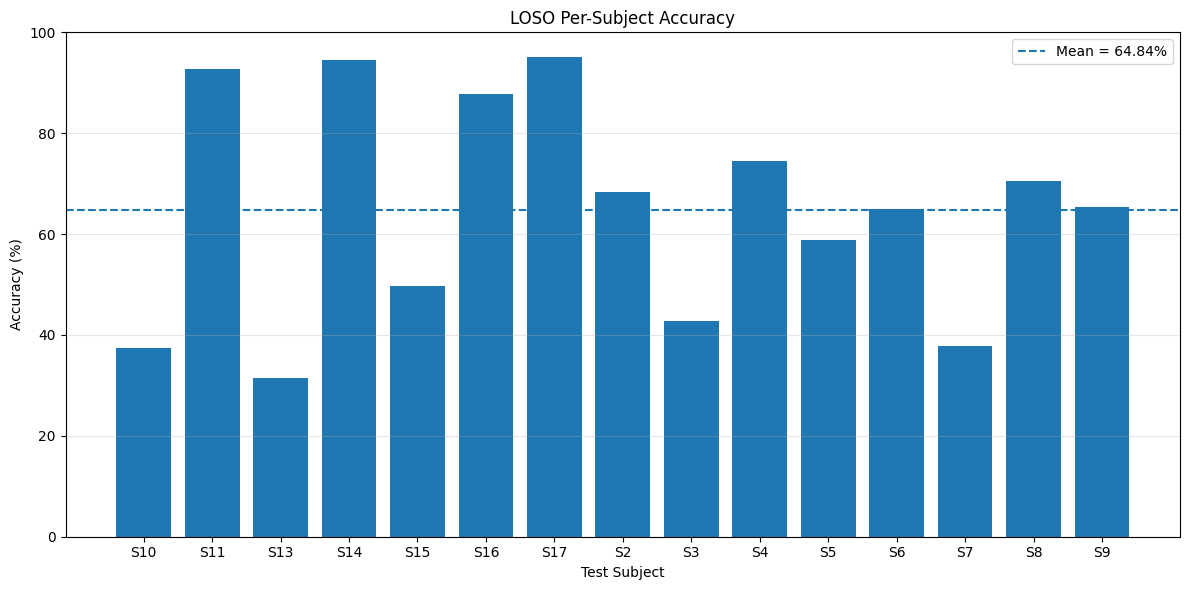

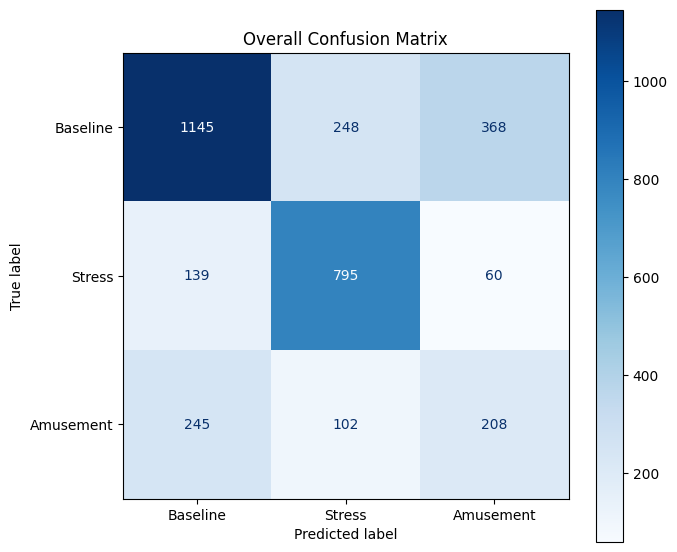


✓ 15 SUBJECT ACCURACIES AVAILABLE
✓ CLASSIFICATION REPORT GENERATED
✓ CONFUSION MATRIX GENERATED
✓ PER-SUBJECT ACCURACY PLOT GENERATED
✓ CONFUSION MATRIX PLOT GENERATED
✓ STEP 11 PASSED


In [17]:
# ============================================================
# STEP 11 — RESULTS ANALYSIS & VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("=" * 70)
print("STEP 11 — RESULTS ANALYSIS & VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check that Step 10 results exist
# ------------------------------------------------------------

required_variables = [
    "loso_accuracies",
    "overall_true",
    "overall_pred"
]

missing = [v for v in required_variables if v not in globals()]

if missing:
    raise NameError(
        f"Missing Step 10 variables: {missing}\n"
        "Please run Step 10 first."
    )

# ------------------------------------------------------------
# 2. Per-subject accuracy
# ------------------------------------------------------------

subjects = list(np.unique(groups_all))

print("\nPer-Subject Accuracy:")
print("-" * 40)

for subject, acc in zip(subjects, loso_accuracies):
    print(f"{str(subject):<8}: {acc * 100:.2f}%")

# ------------------------------------------------------------
# 3. Mean and standard deviation
# ------------------------------------------------------------

mean_acc = np.mean(loso_accuracies)
std_acc = np.std(loso_accuracies)

print("\nLOSO Performance:")
print("-" * 40)
print(f"Mean Accuracy : {mean_acc * 100:.2f}%")
print(f"Std Accuracy  : {std_acc * 100:.2f}%")

# ------------------------------------------------------------
# 4. Overall classification report
# ------------------------------------------------------------

class_names = [
    "Baseline",
    "Stress",
    "Amusement"
]

report = classification_report(
    overall_true,
    overall_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nOverall Classification Report:")
print("-" * 40)
print(report)

# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    overall_true,
    overall_pred,
    labels=[0, 1, 2]
)

print("\nOverall Confusion Matrix:")
print("-" * 40)
print(cm)

# ------------------------------------------------------------
# 6. Plot — Per Subject Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    [str(s) for s in subjects],
    np.array(loso_accuracies) * 100
)

plt.axhline(
    mean_acc * 100,
    linestyle="--",
    label=f"Mean = {mean_acc * 100:.2f}%"
)

plt.xlabel("Test Subject")
plt.ylabel("Accuracy (%)")
plt.title("LOSO Per-Subject Accuracy")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Plot — Confusion Matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=True
)

ax.set_title("Overall Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. STEP 11 validation
# ------------------------------------------------------------

assert len(loso_accuracies) == 15
assert len(overall_true) == len(overall_pred)
assert cm.shape == (3, 3)

print("\n" + "=" * 70)
print("✓ 15 SUBJECT ACCURACIES AVAILABLE")
print("✓ CLASSIFICATION REPORT GENERATED")
print("✓ CONFUSION MATRIX GENERATED")
print("✓ PER-SUBJECT ACCURACY PLOT GENERATED")
print("✓ CONFUSION MATRIX PLOT GENERATED")
print("✓ STEP 11 PASSED")
print("=" * 70)

In [18]:
# ============================================================
# STEP 12 — FINAL RESULTS TABLE & CSV
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

print("=" * 70)
print("STEP 12 — FINAL RESULTS TABLE & CSV")
print("=" * 70)

# ------------------------------------------------------------
# CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "subject_results",
    "loso_accuracies",
    "overall_true",
    "overall_pred"
]

missing = [
    v for v in required_variables
    if v not in globals()
]

if missing:
    raise NameError(
        f"Missing variables: {missing}\n"
        "Please run Step 10 Final and Step 11 first."
    )

# ------------------------------------------------------------
# 1. PER-SUBJECT RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(subject_results)

results_df["accuracy_percent"] = (
    results_df["accuracy"] * 100
)

results_df = results_df[
    [
        "subject",
        "samples",
        "accuracy_percent"
    ]
]

results_df.columns = [
    "Subject",
    "Test Samples",
    "Accuracy (%)"
]

# ------------------------------------------------------------
# 2. ADD SUMMARY ROWS
# ------------------------------------------------------------

mean_accuracy = np.mean(
    loso_accuracies
) * 100

std_accuracy = np.std(
    loso_accuracies
) * 100

overall_accuracy = (
    np.mean(
        overall_true == overall_pred
    ) * 100
)

summary_df = pd.DataFrame({
    "Subject": [
        "Mean LOSO",
        "Std LOSO",
        "Overall"
    ],
    "Test Samples": [
        len(overall_true),
        len(overall_true),
        len(overall_true)
    ],
    "Accuracy (%)": [
        mean_accuracy,
        std_accuracy,
        overall_accuracy
    ]
})

final_table = pd.concat(
    [results_df, summary_df],
    ignore_index=True
)

# ------------------------------------------------------------
# 3. CLASS-WISE METRICS
# ------------------------------------------------------------

report_dict = classification_report(
    overall_true,
    overall_pred,
    labels=[0, 1, 2],
    target_names=[
        "Baseline",
        "Stress",
        "Amusement"
    ],
    output_dict=True,
    zero_division=0
)

class_metrics = pd.DataFrame({
    "Class": [
        "Baseline",
        "Stress",
        "Amusement"
    ],
    "Precision": [
        report_dict["Baseline"]["precision"],
        report_dict["Stress"]["precision"],
        report_dict["Amusement"]["precision"]
    ],
    "Recall": [
        report_dict["Baseline"]["recall"],
        report_dict["Stress"]["recall"],
        report_dict["Amusement"]["recall"]
    ],
    "F1-Score": [
        report_dict["Baseline"]["f1-score"],
        report_dict["Stress"]["f1-score"],
        report_dict["Amusement"]["f1-score"]
    ],
    "Support": [
        report_dict["Baseline"]["support"],
        report_dict["Stress"]["support"],
        report_dict["Amusement"]["support"]
    ]
})

# ------------------------------------------------------------
# 4. DISPLAY PER-SUBJECT TABLE
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("PER-SUBJECT RESULTS")
print("=" * 70)

display(
    final_table.style.format({
        "Accuracy (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# 5. DISPLAY CLASS METRICS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CLASS-WISE PERFORMANCE")
print("=" * 70)

display(
    class_metrics.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 6. FINAL SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    f"Mean LOSO Accuracy : "
    f"{mean_accuracy:.2f}%"
)

print(
    f"Std LOSO Accuracy  : "
    f"{std_accuracy:.2f}%"
)

print(
    f"Overall Accuracy   : "
    f"{overall_accuracy:.2f}%"
)

print(
    f"Macro F1           : "
    f"{report_dict['macro avg']['f1-score']:.4f}"
)

print(
    f"Weighted F1        : "
    f"{report_dict['weighted avg']['f1-score']:.4f}"
)

# ------------------------------------------------------------
# 7. SAVE CSV FILES
# ------------------------------------------------------------

subject_csv_path = (
    "/content/LOSO_subject_results.csv"
)

class_csv_path = (
    "/content/class_wise_results.csv"
)

final_table.to_csv(
    subject_csv_path,
    index=False
)

class_metrics.to_csv(
    class_csv_path,
    index=False
)

# ------------------------------------------------------------
# 8. SAVE COMPLETE SUMMARY
# ------------------------------------------------------------

summary_path = (
    "/content/final_model_summary.txt"
)

with open(
    summary_path,
    "w"
) as f:

    f.write(
        "WESAD Stress Detection — Final Results\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    f.write(
        f"Mean LOSO Accuracy: "
        f"{mean_accuracy:.2f}%\n"
    )

    f.write(
        f"Std LOSO Accuracy: "
        f"{std_accuracy:.2f}%\n"
    )

    f.write(
        f"Overall Accuracy: "
        f"{overall_accuracy:.2f}%\n"
    )

    f.write(
        f"Macro F1: "
        f"{report_dict['macro avg']['f1-score']:.4f}\n"
    )

    f.write(
        f"Weighted F1: "
        f"{report_dict['weighted avg']['f1-score']:.4f}\n"
    )

# ------------------------------------------------------------
# 9. FINAL CHECKS
# ------------------------------------------------------------

assert len(results_df) == 15
assert len(class_metrics) == 3
assert len(overall_true) == 3310
assert len(overall_pred) == 3310

print("\n")
print("=" * 70)
print("FILES SAVED")
print("=" * 70)

print(subject_csv_path)
print(class_csv_path)
print(summary_path)

print("\n")
print("=" * 70)
print("✓ 15 SUBJECT RESULTS CREATED")
print("✓ CLASS-WISE METRICS CREATED")
print("✓ FINAL SUMMARY CREATED")
print("✓ CSV FILES SAVED")
print("✓ STEP 12 PASSED")
print("=" * 70)

STEP 12 — FINAL RESULTS TABLE & CSV


PER-SUBJECT RESULTS


,Subject,Test Samples,Accuracy (%)
0,S10,227,37.44
1,S11,223,92.83
2,S13,222,31.53
3,S14,222,94.59
4,S15,223,49.78
5,S16,222,87.84
6,S17,227,95.15
7,S2,212,68.40
8,S3,215,42.79
9,S4,216,74.54




CLASS-WISE PERFORMANCE


,Class,Precision,Recall,F1-Score,Support
0,Baseline,0.7489,0.6502,0.6960,1761.000000
1,Stress,0.6943,0.7998,0.7433,994.000000
2,Amusement,0.3270,0.3748,0.3493,555.000000




FINAL MODEL SUMMARY
Mean LOSO Accuracy : 64.84%
Std LOSO Accuracy  : 20.96%
Overall Accuracy   : 64.89%
Macro F1           : 0.5962
Weighted F1        : 0.6521


FILES SAVED
/content/LOSO_subject_results.csv
/content/class_wise_results.csv
/content/final_model_summary.txt


✓ 15 SUBJECT RESULTS CREATED
✓ CLASS-WISE METRICS CREATED
✓ FINAL SUMMARY CREATED
✓ CSV FILES SAVED
✓ STEP 12 PASSED
